In [ ]:
# ==============================================================================
# DATA SOURCE
import yfinance as yf
# ==============================================================================
# DATA MANIPULATION
import pandas as pd
import numpy as np
# ==============================================================================
# DATA VISUALIZATION
import seaborn as sns
import matplotlib.pyplot as plt
# ==============================================================================
# Statistical Models and ML
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson, jarque_bera


# ==============================================================================
# RHS FACTORS (The "Explainers")
# These are the systematic drivers used to attribute the returns of the LHS.
# ==============================================================================
# -------------------------
# Equity Factors
# -------------------------
equity_factors = {
    'MKT_EQ': 'SPY',   # Equity market factor, broad US market exposure
    'SMB_EQ': 'IWM',   # Size proxy, small vs large cap tilt
    'HML_EQ': 'VTV',   # Value proxy, high book-to-market style
    'MKT_VOL': '^VIX', # Market uncertainty / risk aversion
    'MOM_EQ':  'PDP',# Focuses on momentum investing in U.S. stocks
    'TECH_EQ': 'XLK',
    'NASDAQ_EQ': 'QQQ',
}

# -------------------------
# Bond Factors
# -------------------------
bond_factors = {
    'TERM_BND': 'TLT',        # Term premium, long duration exposure
    'CREDIT_BND': 'LQD',      # Credit spread, investment grade corporate risk
    'LRF_BND': 'BND'  ,       # Liquidity Risk
   # 'Default_BND' : 'HYG',   # Default Risk
}

# -------------------------
# Commodity Factors
# -------------------------
commodity_factors = {
    'COMM_BASKET': 'DBC',  # Broad commodity basket exposure
    'OIL_MACRO': 'USO'  ,   # Crude oil price exposure
    'ENERGY_EQ': 'XLE',
    'DOLLAR_MACRO': 'UUP',
}

# -------------------------
# Risk-Free Proxy
# -------------------------
risk_free_proxy = 'SHV'   # Short-term Treasury ETF as cash / risk-free rate proxy


# ==============================================================================
# LHS TARGETS (The "Assets to be Explained")
# ==============================================================================
lhs_assets = {
    'EQUITY_LHS': 'AAPL',  # Apple
    'BOND_LHS': 'AGG',     # Investment Grade Corp Bond ETF
    'COMM_LHS': 'XOM'      # Exxon Mobil (as a proxy for energy/commodity equity)
}

# ==============================================================================
# UTILITY FUNCTIONS
# ==============================================================================


def _pick_prices(raw: pd.DataFrame) -> pd.DataFrame:
    """Robustly pick price panel from yfinance output."""
    if isinstance(raw.columns, pd.MultiIndex):
        if "Adj Close" in raw.columns.levels[0]:
            return raw["Adj Close"]
        return raw["Close"]
    return raw.get("Adj Close", raw.get("Close"))

def build_factor_panel(start_date="2008-01-01", interval="1wk") -> pd.DataFrame:
    """
    Downloads factor tickers once, returns monthly excess returns panel:
    columns = factor names (MKT_EQ, TERM_BND, etc.) and RF_RATE column.
    """
    factor_map = {**equity_factors, **bond_factors, **commodity_factors}  # name -> ticker
    tickers = sorted(set(factor_map.values()) | {risk_free_proxy})

    raw = yf.download(
        tickers,
        start=start_date,
        interval=interval,
        auto_adjust=False,
        group_by="column"
    )

    prices = _pick_prices(raw)
    if prices is None:
        raise ValueError("Could not find price columns: neither 'Adj Close' nor 'Close' found.")

    rets = prices.pct_change().dropna()

    # rename tickers -> factor names + RF
    rename_map = {v: k for k, v in factor_map.items()}
    rename_map[risk_free_proxy] = "RF_RATE"
    rets = rets.rename(columns=rename_map)

    # factor excess returns
    rf = rets["RF_RATE"]
    factor_excess = rets.drop(columns=["RF_RATE"]).sub(rf, axis=0)
    factor_excess["RF_RATE"] = rf  # keep RF if you want it for reference

    return factor_excess

def build_lhs_excess(target_ticker: str, start_date="2007-01-01", interval="1wk") -> pd.Series:
    """Downloads one LHS ticker and returns its monthly excess return series named LHS_TARGET."""
    raw = yf.download(
        [target_ticker, risk_free_proxy],
        start=start_date,
        interval=interval,
        auto_adjust=False,
        group_by="column"
    )

    prices = _pick_prices(raw)
    if prices is None:
        raise ValueError("Could not find price columns: neither 'Adj Close' nor 'Close' found.")

    rets = prices.pct_change().dropna()

    lhs_ret = rets[target_ticker]
    rf = rets[risk_free_proxy]
    lhs_excess = (lhs_ret - rf).rename("LHS_TARGET")

    return lhs_excess

def get_factor_model_df(target_key: str, factor_panel: pd.DataFrame, start_date="2007-01-01", interval="1wk") -> pd.DataFrame:
    """Joins precomputed factor excess returns with one LHS excess return series."""
    target_ticker = lhs_assets[target_key]
    lhs_excess = build_lhs_excess(target_ticker, start_date=start_date, interval=interval)

    # align index and join
    df = factor_panel.join(lhs_excess, how="inner")
    # For regression you typically want: LHS_TARGET plus RHS factors (exclude RF_RATE)
    cols = ["LHS_TARGET"] + [c for c in df.columns if c not in ("LHS_TARGET", "RF_RATE")]
    return df[cols]

# ==============================================================================
# RUN ONCE
# ==============================================================================
start_date = "2007-01-01"  # use longer history;
factor_panel = build_factor_panel(start_date=start_date, interval="1wk") #building factor panel



[*********************100%***********************]  15 of 15 completed


In [ ]:
# ==============================================================================
# Using factor panels to build LHS
df_apple = get_factor_model_df("EQUITY_LHS", factor_panel, start_date=start_date, interval="1wk")
df_bond  = get_factor_model_df("BOND_LHS",   factor_panel, start_date=start_date, interval="1wk")
df_exxon = get_factor_model_df("COMM_LHS",   factor_panel, start_date=start_date, interval="1wk")

#===============================================================================
# Testing - Run each one individually to view
#factor_panel
#df_apple
#df_bond
#df_exxon
# ==============================================================================

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  2 of 2 completed


In [ ]:
df_apple

,LHS_TARGET,LRF_BND,COMM_BASKET,SMB_EQ,CREDIT_BND,MOM_EQ,NASDAQ_EQ,MKT_EQ,TERM_BND,OIL_MACRO,DOLLAR_MACRO,HML_EQ,ENERGY_EQ,TECH_EQ,MKT_VOL
Date,,,,,,,,,,,,,,,
2007-04-16,0.007174,0.003756,-0.007530,0.010761,0.006046,0.012439,0.015882,0.021792,0.010908,-0.029448,-0.010231,0.022017,-0.000123,0.013316,-0.011571
2007-04-23,0.097560,-0.001090,0.009751,0.001726,0.000764,0.010028,0.024947,0.005299,-0.004455,0.034940,0.002446,0.003800,0.015499,0.014859,0.030659
2007-04-30,0.010736,0.003158,-0.010187,0.005464,0.002389,0.000295,0.003117,0.011124,0.010595,-0.066458,0.004274,0.010894,0.009937,0.018082,0.038776
2007-05-07,0.074710,-0.003065,-0.009445,-0.009749,-0.000976,0.006799,-0.000736,-0.004351,-0.004933,0.001637,0.004584,0.000885,0.004709,0.003243,-0.000855
2007-05-14,0.010581,-0.005705,0.001966,-0.008598,-0.007911,-0.003849,-0.002686,0.010477,-0.015477,0.030311,-0.000383,0.010090,0.038988,0.003575,-0.015861
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-09,-0.031908,-0.009679,0.040222,-0.020538,-0.018084,-0.009090,-0.013453,-0.018405,-0.021850,0.098835,0.011891,-0.017197,0.016577,-0.006968,-0.081391
2026-03-16,-0.008969,-0.005620,0.007558,-0.018175,-0.003412,-0.006924,-0.020092,-0.021170,-0.008658,0.012392,-0.007983,-0.014394,0.027449,-0.011492,-0.015533
2026-03-23,0.002541,-0.001545,0.004803,0.004693,-0.002858,-0.013752,-0.034193,-0.020381,-0.002939,0.022086,0.005055,-0.006740,0.054071,-0.040418,0.158722


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 991 entries, 2007-04-16 to 2026-04-06
Freq: W-MON
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   LHS_TARGET    991 non-null    float64
 1   LRF_BND       991 non-null    float64
 2   COMM_BASKET   991 non-null    float64
 3   SMB_EQ        991 non-null    float64
 4   CREDIT_BND    991 non-null    float64
 5   MOM_EQ        991 non-null    float64
 6   NASDAQ_EQ     991 non-null    float64
 7   MKT_EQ        991 non-null    float64
 8   TERM_BND      991 non-null    float64
 9   OIL_MACRO     991 non-null    float64
 10  DOLLAR_MACRO  991 non-null    float64
 11  HML_EQ        991 non-null    float64
 12  ENERGY_EQ     991 non-null    float64
 13  TECH_EQ       991 non-null    float64
 14  MKT_VOL       991 non-null    float64
dtypes: float64(15)
memory usage: 123.9 KB
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 991 entries, 2007-04-16 to 2026-04-06

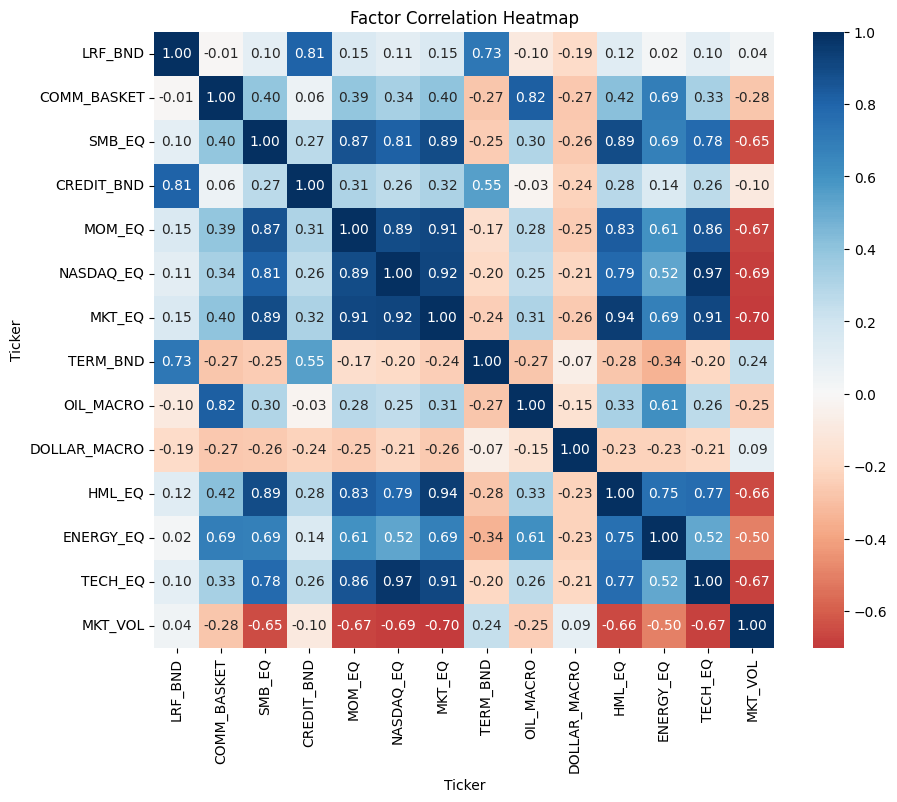

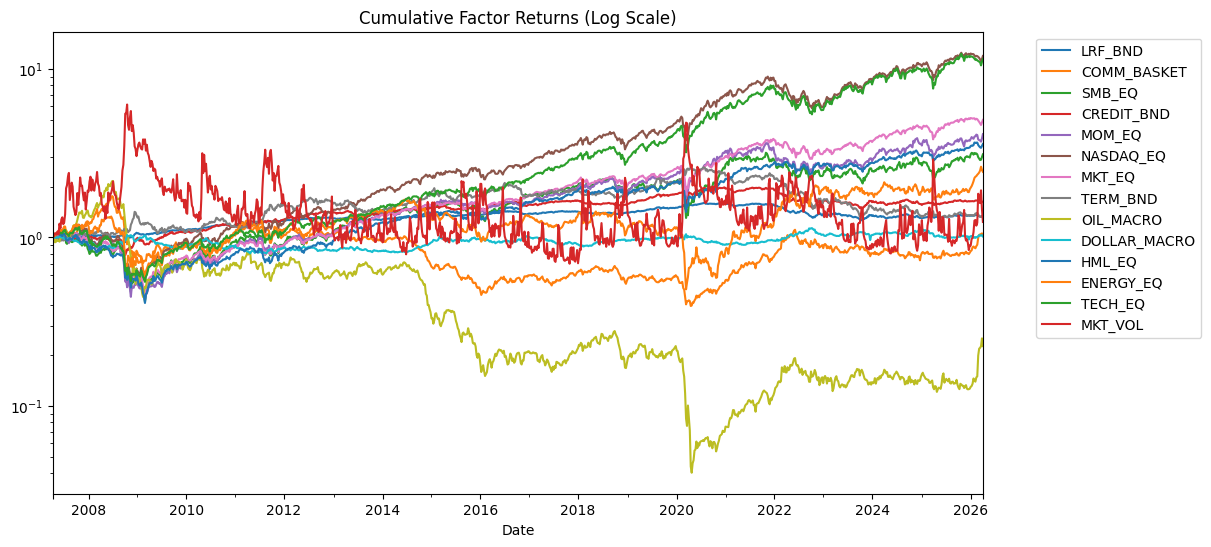

=== UNIVARIATE ANALYSIS: DISTRIBUTIONS ===


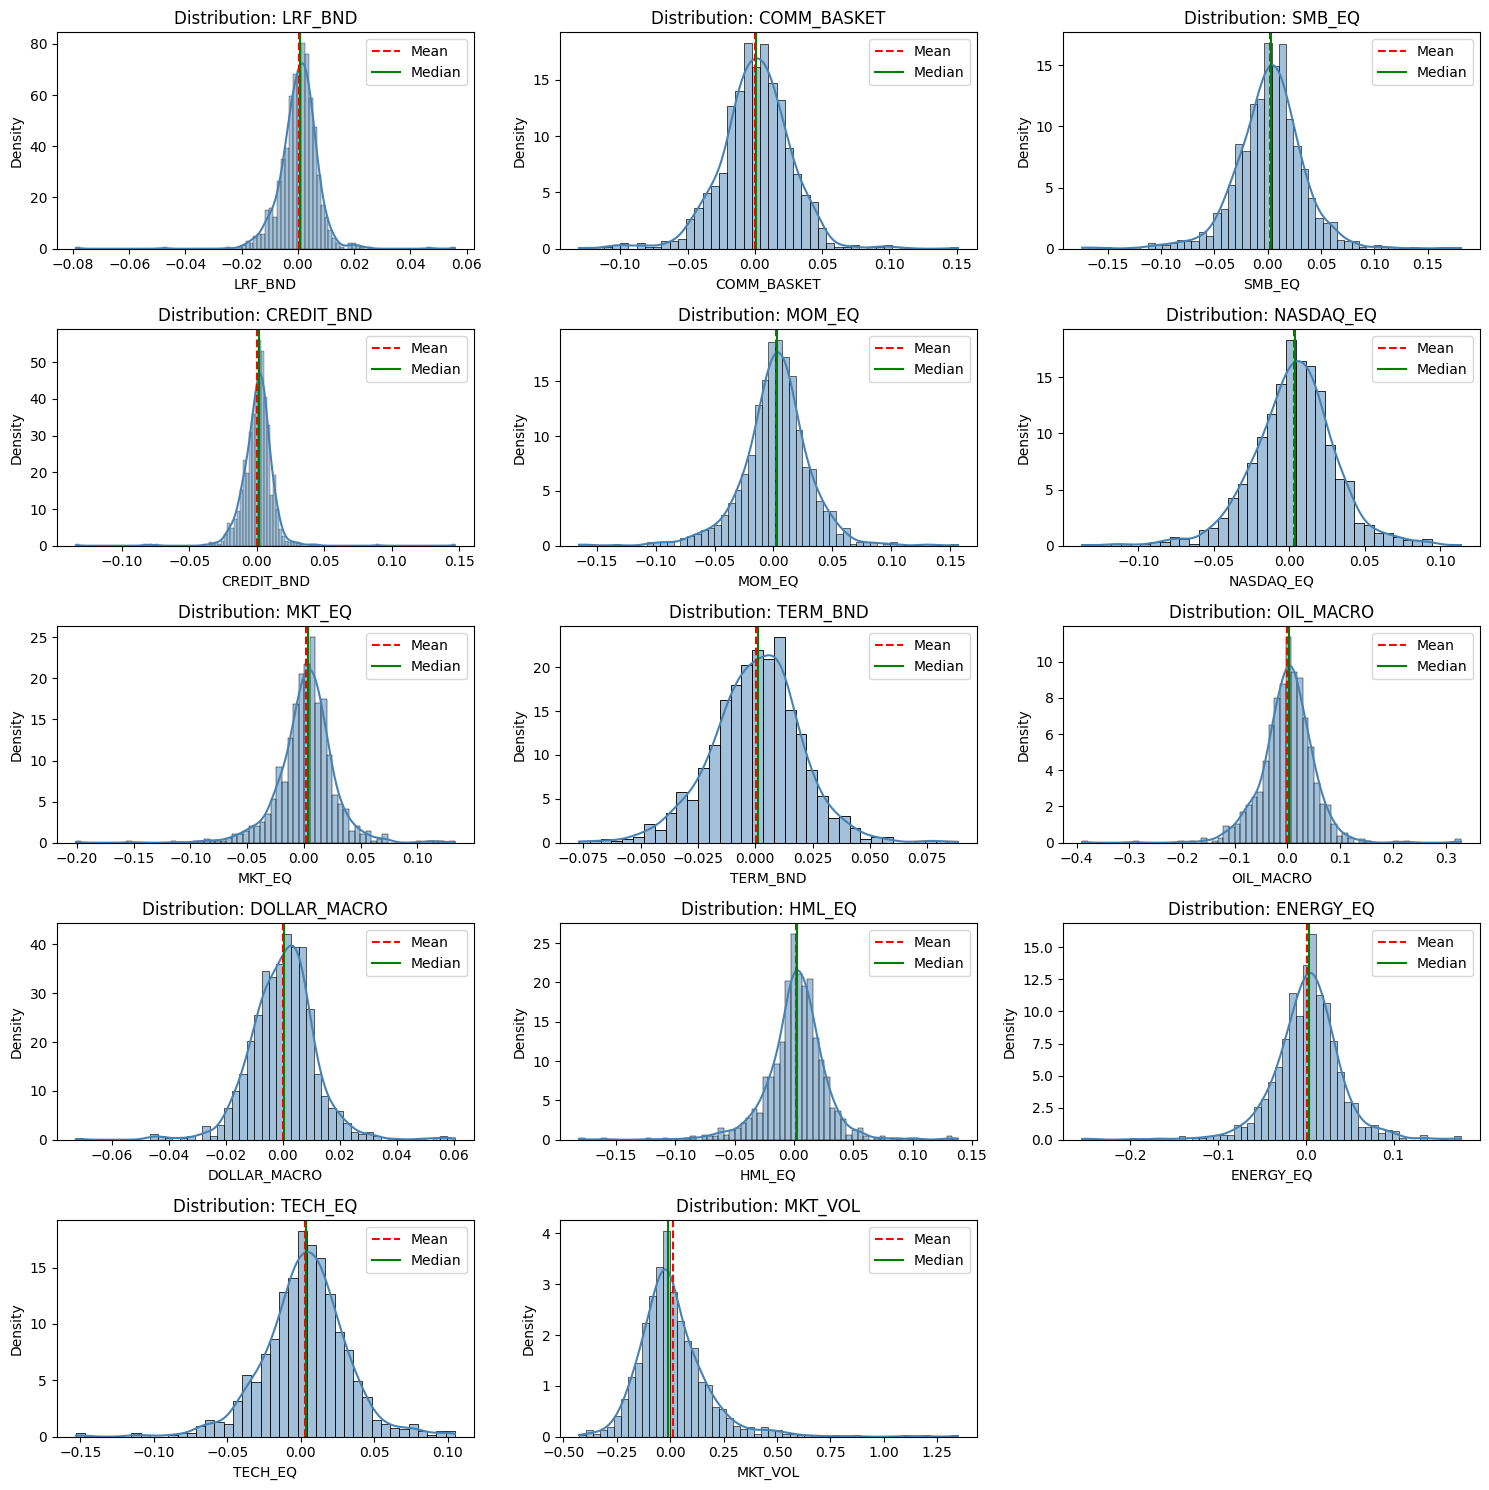


=== BIVARIATE ANALYSIS: ASSET VS. PRIMARY DRIVER ===


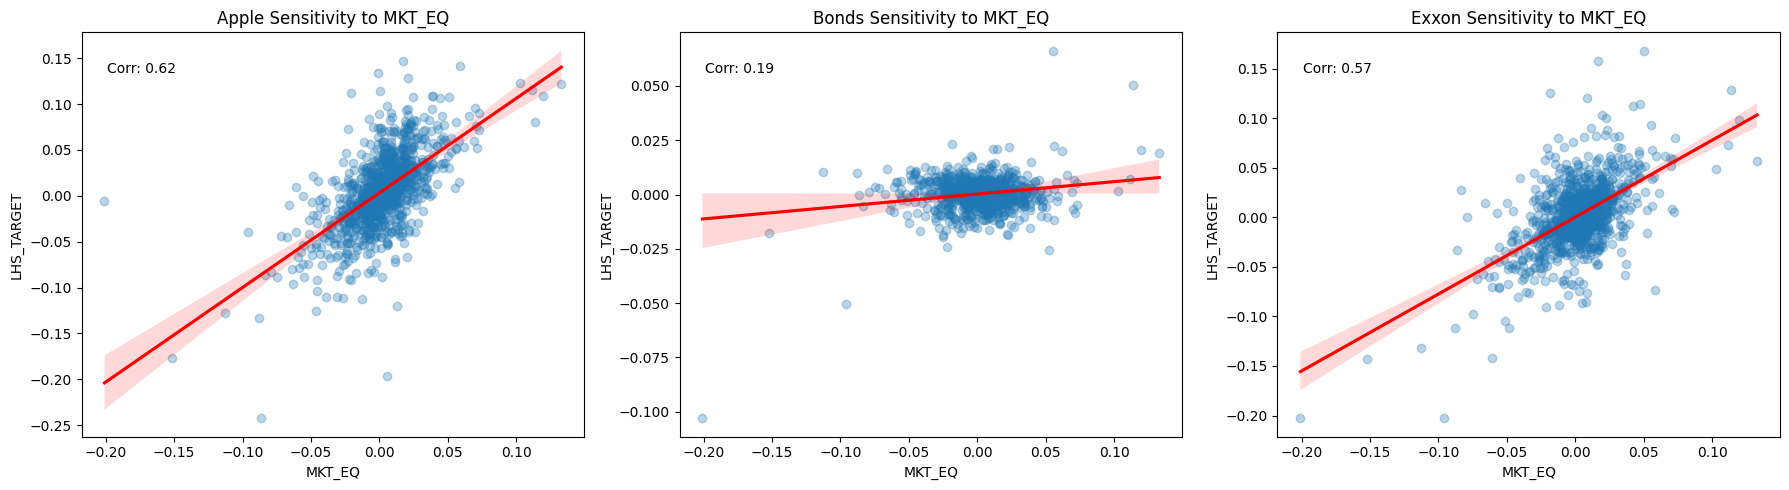


=== BIVARIATE ANALYSIS: FACTOR CLUSTERS ===


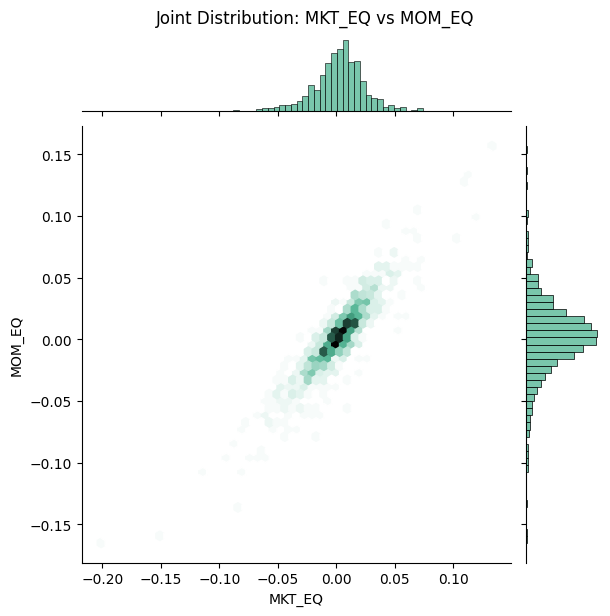

In [ ]:
# ==============================================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================

# ✅ Alignment Checks
# ✅ Missing Data Detection
# ✅ Data Type Validation
# No missing observations, data types align --> Regression Ready

#-------------------------
df_apple.info()
df_apple.describe().T
#-------------------------
df_bond.info()
df_bond.describe().T
#-------------------------
df_exxon.info()
df_exxon.describe().T
#-------------------------
df_apple.isna().sum()
df_bond.isna().sum()
df_exxon.isna().sum()
#-------------------------

# ------------------------------------------------------------------------------
# 1. DATA INTEGRITY & OVERVIEW
# ------------------------------------------------------------------------------
def run_data_integrity(factor_panel, target_dfs):
    print("\n\n=== 1. DATA INTEGRITY CHECK ===")
    # Check for missing values and alignment
    print(f"Date Range: {factor_panel.index.min().date()} to {factor_panel.index.max().date()}")
    print(f"Total Periods: {len(factor_panel)} months")

    # Unified Null Check
    null_counts = factor_panel.isnull().sum()
    if null_counts.sum() == 0:
        print("\n✅ All factors: No missing values.")
    else:
        print("\n⚠️ Missing values detected:")
        print(null_counts[null_counts > 0])

    print("\nnLHS Asset Samples:")
    for name, df in target_dfs.items():
        print(f"• {name:10}: {len(df)} observations")
    print("-" * 50)

# -----------------------------------------------------------------------------
# 2. DESCRIPTIVE STATISTICS (The "What" of the data)
# -----------------------------------------------------------------------------
def run_descriptive_stats(factor_panel):
    print("\n=== 2. DESCRIPTIVE STATISTICS ===")

    # Focusing on mean, risk, and distribution shape
    factors_only = factor_panel.drop(columns=['RF_RATE'])
    stats = factors_only.describe().T
    stats['skew'] = factors_only.skew()
    stats['kurtosis'] = factors_only.kurtosis()

    # Printing a clean version of the stats
    print(stats[['mean', 'std', 'min', 'max', 'skew', 'kurtosis']].to_string())

# -----------------------------------------------------------------------------
# 3. VISUAL RELATIONSHIPS (The "How" of the data)
# -----------------------------------------------------------------------------
def run_visual_eda(factor_panel, target_dfs):
    print("\n=== 3. VISUAL RELATIONSHIPS (HEATMAP & TRENDS) ===")

    # A. Correlation Heatmap (Visual Redundancy Check)
    plt.figure(figsize=(10, 8))
    factors_only = factor_panel.drop(columns=['RF_RATE'])
    sns.heatmap(factors_only.corr(), annot=True, cmap='RdBu', center=0, fmt=".2f")
    plt.title("Factor Correlation Heatmap")
    plt.show()

    # B. Cumulative Returns (Economic Reality Check)
    # Shows if the factors actually represent growth or risk over time
    plt.figure(figsize=(12, 6))
    (1 + factors_only).cumprod().plot(ax=plt.gca())
    plt.yscale('log')
    plt.title("Cumulative Factor Returns (Log Scale)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

# -----------------------------------------------------------------------------
# 4. ADDITIONAL ALIGNMENT CHECK LHS=RHS
# -----------------------------------------------------------------------------
def run_lhs_alignment_checks(factor_panel, target_dfs):
    print("\n=== LHS–RHS ALIGNMENT & NULL CHECK ===")

    rhs_index = factor_panel.index
    rhs_cols = set(factor_panel.columns)

    print(f"RHS (Factor Panel) Periods: {len(rhs_index)}")

    for name, df in target_dfs.items():
        print(f"\n--- {name} ---")

        lhs_index = df.index

        # 1) Index overlap
        common_index = rhs_index.intersection(lhs_index)
        print(f"Overlap Periods: {len(common_index)}")

        if len(common_index) < len(rhs_index):
            print("⚠️ LHS does not fully cover RHS date range")

        if len(common_index) < len(lhs_index):
            print("⚠️ RHS does not fully cover LHS date range")

        # 2) Exact alignment check
        is_aligned = rhs_index.equals(lhs_index)
        print(f"Exact Index Match: {'✅ Yes' if is_aligned else '❌ No'}")

        # 3) Missing dates diagnostics
        missing_in_lhs = rhs_index.difference(lhs_index)
        missing_in_rhs = lhs_index.difference(rhs_index)

        if len(missing_in_lhs) > 0:
            print(f"Dates missing in LHS (sample): {list(missing_in_lhs[:5])}")

        if len(missing_in_rhs) > 0:
            print(f"Dates missing in RHS (sample): {list(missing_in_rhs[:5])}")

        # 4) Null checks in the full df
        nulls = df.isnull().sum()
        if nulls.sum() == 0:
            print("✅ No null values in target dataframe")
        else:
            print("⚠️ Null values detected:")
            print(nulls[nulls > 0])

        # 5) Check whether RHS columns are already embedded
        overlapping_rhs = rhs_cols.intersection(df.columns)

        if overlapping_rhs:
            print("✅ Target dataframe already includes factor columns")
            rhs_nulls = df[list(overlapping_rhs)].isnull().sum().sum()
            lhs_nulls = df['LHS_TARGET'].isnull().sum() if 'LHS_TARGET' in df.columns else None

            if lhs_nulls == 0:
                print("✅ LHS_TARGET has no nulls")
            else:
                print(f"⚠️ LHS_TARGET null count: {lhs_nulls}")

            if rhs_nulls == 0:
                print("✅ Embedded RHS factor columns have no nulls")
            else:
                print(f"⚠️ Embedded RHS factor null count: {rhs_nulls}")
        else:
            print("ℹ️ Target dataframe does not yet include factor columns")


# =============================================================================
# Bivariate Dependence & Factor Exposure Analysis
# =============================================================================


def run_univariate_analysis(factor_panel):
    print("=== UNIVARIATE ANALYSIS: DISTRIBUTIONS ===")
    f = factor_panel.drop(columns=['RF_RATE'])

    # Setup plotting grid
    n_cols = 3
    n_rows = (len(f.columns) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
    axes = axes.flatten()

    for i, col in enumerate(f.columns):
        # Histogram with KDE (Kernel Density Estimate)
        sns.histplot(f[col], kde=True, ax=axes[i], color='steelblue', stat="density")
        axes[i].set_title(f"Distribution: {col}")

        # Add mean and median lines to visualize skewness
        axes[i].axvline(f[col].mean(), color='red', linestyle='--', label='Mean')
        axes[i].axvline(f[col].median(), color='green', linestyle='-', label='Median')
        # Adds the legend for the mean and median
        axes[i].legend()

    # Remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    # There is duplication!!
    # Summary Table for Skew and Kurtosis
    #dist_stats = pd.DataFrame({
        #'Skewness': f.skew(),
        #'Kurtosis': f.kurtosis()
    #})
   # print(dist_stats)

def run_bivariate_analysis(target_dfs, names, primary_factor='MKT_EQ'):
    print("\n=== BIVARIATE ANALYSIS: ASSET VS. PRIMARY DRIVER ===")
    fig, axes = plt.subplots(1, len(target_dfs), figsize=(18, 5))

    for i, (df, name) in enumerate(zip(target_dfs, names)):
        # Scatter plot with a regression line (The Visual Beta)
        sns.regplot(
            x=primary_factor,
            y='LHS_TARGET',
            data=df,
            ax=axes[i],
            scatter_kws={'alpha': 0.3},
            line_kws={'color': 'red'}
        )
        axes[i].set_title(f"{name} Sensitivity to {primary_factor}")

        # Calculate raw correlation coefficient for the plot
        corr_val = df[primary_factor].corr(df['LHS_TARGET'])
        axes[i].annotate(f'Corr: {corr_val:.2f}', xy=(0.05, 0.9), xycoords='axes fraction')

    plt.tight_layout()
    plt.show()

def run_bivariate_factor_clusters(factor_panel, x_factor='MKT_EQ', y_factor='MOM_EQ'):
    print("\n=== BIVARIATE ANALYSIS: FACTOR CLUSTERS ===")
    # Visualizing how two potentially redundant factors move together
    # Example: Market Equity vs Momentum
    factors = factor_panel.drop(columns=['RF_RATE'])

    sns.jointplot(x=x_factor, y=y_factor, data=factors, kind="hex", color="#4CB391")
    plt.suptitle(f"Joint Distribution: {x_factor} vs {y_factor}", y=1.02)
    plt.show()

# =============================================================================
# EXECUTION
# =============================================================================
target_dict = {"Apple": df_apple, "Bonds": df_bond, "Exxon": df_exxon}

run_data_integrity(factor_panel, target_dict)
run_lhs_alignment_checks(factor_panel, target_dict)
run_descriptive_stats(factor_panel)
run_visual_eda(factor_panel, target_dict)

run_univariate_analysis(factor_panel)
run_bivariate_analysis([df_apple, df_bond, df_exxon], ["Apple", "Bonds", "Exxon"])
run_bivariate_factor_clusters(factor_panel)


In [ ]:
def drop_correlated_with_priority(
    factor_panel,
    threshold=0.85,
    priority_factors=None,
    exclude_cols=['RF_RATE']
):
    """
    Drops highly correlated factors while preserving priority factors.
    """
    if priority_factors is None:
        priority_factors = []

    factors = factor_panel.drop(columns=exclude_cols)
    corr = factors.corr().abs()

    to_drop = set()

    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):
            col_i = corr.columns[i]
            col_j = corr.columns[j]

            if corr.iloc[i, j] > threshold:
                if col_i in priority_factors and col_j not in priority_factors:
                    to_drop.add(col_j)
                elif col_j in priority_factors and col_i not in priority_factors:
                    to_drop.add(col_i)
                else:
                    to_drop.add(col_j)

    print("Dropping correlated factors (priority-aware):")
    for col in sorted(to_drop):
        print(f" - {col}")

    return factor_panel.drop(columns=list(to_drop)), list(to_drop)

In [ ]:
priority = ['MKT_EQ', 'TERM_BND', 'MKT_VOL', 'OIL_MACRO']

factor_panel_reduced, dropped_factors = drop_correlated_with_priority(
    factor_panel,
    threshold=0.85,
    priority_factors=priority
)

print("Dropped factors:", dropped_factors)
print("Remaining factors:", factor_panel_reduced.columns.tolist())

Dropping correlated factors (priority-aware):
 - HML_EQ
 - MOM_EQ
 - NASDAQ_EQ
 - SMB_EQ
 - TECH_EQ
Dropped factors: ['SMB_EQ', 'HML_EQ', 'NASDAQ_EQ', 'MOM_EQ', 'TECH_EQ']
Remaining factors: ['LRF_BND', 'COMM_BASKET', 'CREDIT_BND', 'MKT_EQ', 'TERM_BND', 'OIL_MACRO', 'DOLLAR_MACRO', 'ENERGY_EQ', 'MKT_VOL', 'RF_RATE']


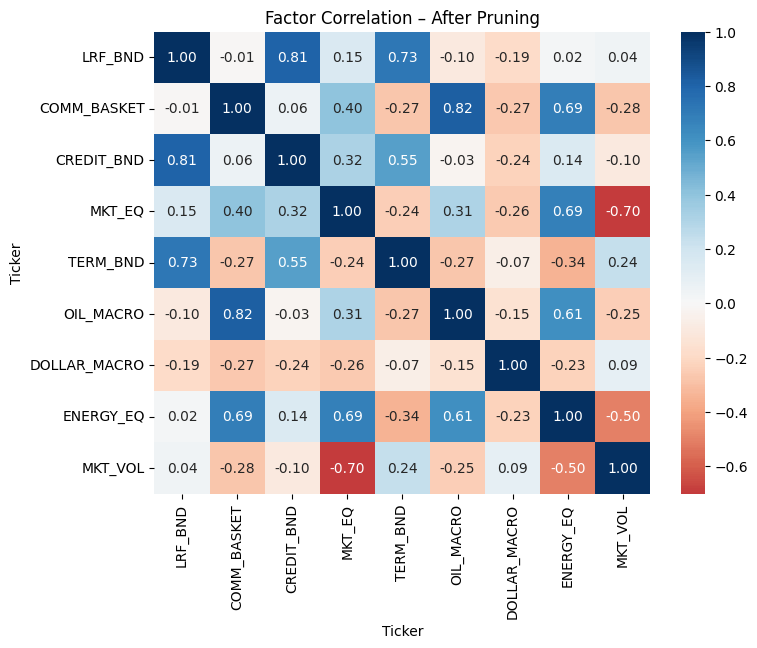

In [ ]:
factors_reduced = factor_panel_reduced.drop(columns=['RF_RATE'])

plt.figure(figsize=(8, 6))
sns.heatmap(
    factors_reduced.corr(),
    annot=True, cmap='RdBu', center=0, fmt=".2f"
)
plt.title("Factor Correlation – After Pruning")
plt.show()

In [ ]:
#===============================================================================
# MODEL ASSUMPTION AND VALIDATION CHECKS
#===============================================================================

# --- NEW: HAC / Newey–West utility
def fit_ols_hac(y, X, maxlags=None):
    """
    Fits OLS with Newey–West (HAC) standard errors.
    """
    X_const = sm.add_constant(X, has_constant="add")

    # Default lag rule (good for monthly data)
    # Newey-West rule of thumb: floor(4*(T/100)^(2/9))
    T = len(y)
    if maxlags is None:
        maxlags = int(4 * (T / 100) ** (2/9))

    model = sm.OLS(y, X_const).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": maxlags}
    )

    return model, maxlags

def align_model_df_to_factor_panel(df_model, factor_panel, lhs_col="LHS_TARGET", rf_col="RF_RATE"):
    """
    Keeps only LHS + factors present in factor_panel (excluding RF).
    Drops rows with NA after alignment.
    """
    factor_cols = [c for c in factor_panel.columns if c != rf_col]
    keep_cols = [lhs_col] + [c for c in factor_cols if c in df_model.columns]

    missing_in_df = [c for c in factor_cols if c not in df_model.columns]
    if missing_in_df:
        print(f"Note: df_model is missing factors (likely from old build): {missing_in_df}")

    return df_model[keep_cols].dropna()


def run_assumption_validation(df_model, asset_name, factor_panel=None, use_robust_if_hetero=True):
    """
    Regression diagnostics on df_model (expects LHS_TARGET and factor columns).
    If factor_panel is provided, first aligns df_model to its factor list.
    """
    print(f"=== ASSUMPTION VALIDATION: {asset_name} ===")

    # 0) Align to updated factor set if provided
    if factor_panel is not None:
        df_model = align_model_df_to_factor_panel(df_model, factor_panel)

    # Basic checks
    if "LHS_TARGET" not in df_model.columns:
        raise ValueError("df_model must contain 'LHS_TARGET'.")

    y = df_model["LHS_TARGET"]
    X = df_model.drop(columns=["LHS_TARGET"])

    # Guard: need at least 1 factor
    if X.shape[1] == 0:
        raise ValueError("No factor columns found after alignment. Rebuild/align your df_model.")

    X_const = sm.add_constant(X, has_constant="add")
    base_model = sm.OLS(y, X_const).fit()

    # 1) VIF (exclude const)
    print("\n1. Multicollinearity (VIF):")
    vif_df = pd.DataFrame({
        "Factor": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).sort_values("VIF", ascending=False)
    print(vif_df.to_string(index=False))

    # 2) ADF (Stationarity)
    print("\n2. Stationarity (ADF Test p-values):")
    for col in df_model.columns:
        series = df_model[col].dropna()
        # ADF can fail if series is constant / too short
        try:
            p_val = adfuller(series)[1]
            flag = "✓" if p_val < 0.05 else "✗"
            print(f" • {col:12}: {p_val:.4f} {flag}")
        except Exception as e:
            print(f" • {col:12}: ADF failed ({type(e).__name__})")

    # 3) Durbin-Watson
    dw = durbin_watson(base_model.resid)
    print(f"\n3. Durbin-Watson: {dw:.2f} (Target ~2.0)")

    # 4) Breusch-Pagan (Heteroskedasticity)
    bp_lm, bp_p, _, _ = het_breuschpagan(base_model.resid, X_const)
    hetero_flag = "✓" if bp_p > 0.05 else "⚠️ Use Robust SE"
    print(f"4. Heteroskedasticity (BP p-val): {bp_p:.4f} {hetero_flag}")

    # Robust Inference Adjustment (Newey–West HAC)
    model = base_model
    use_hac = False
    # Trigger HAC if either issue is detected
    if bp_p <= 0.05 or abs(dw - 2) > 0.5:
        use_hac = True

    if use_hac:
        model, lag_used = fit_ols_hac(y, X)
        print(f"   Refit with Newey–West (HAC), maxlags={lag_used}")

    # 5) Jarque-Bera
    jb_stat, jb_p, _, _ = jarque_bera(model.resid)
    norm_flag = "✓" if jb_p > 0.05 else "✗ Fat Tails"
    print(f"5. Normality (JB p-val): {jb_p:.4f} {norm_flag}")

    print("-" * 60)
    return model, vif_df


def rebuild_lhs_df_from_factor_panel(target_ticker, factor_panel, start_date="2007-01-01", interval="1wk"):
    """
    Builds a fresh df_model = [LHS_TARGET + reduced factor columns]
    using the already-computed factor_panel (excess returns).
    """
    lhs_excess = build_lhs_excess(target_ticker, start_date=start_date, interval=interval)
    df = factor_panel.join(lhs_excess, how="inner")

    # Regression-ready columns: LHS + factors (exclude RF_RATE)
    factor_cols = [c for c in factor_panel.columns if c != "RF_RATE"]
    return df[["LHS_TARGET"] + factor_cols].dropna()


df_apple_new = rebuild_lhs_df_from_factor_panel(lhs_assets["EQUITY_LHS"], factor_panel_reduced)
df_bond_new  = rebuild_lhs_df_from_factor_panel(lhs_assets["BOND_LHS"],   factor_panel_reduced)
df_exxon_new = rebuild_lhs_df_from_factor_panel(lhs_assets["COMM_LHS"],   factor_panel_reduced)

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  2 of 2 completed


In [ ]:
df_apple_new

,LHS_TARGET,LRF_BND,COMM_BASKET,CREDIT_BND,MKT_EQ,TERM_BND,OIL_MACRO,DOLLAR_MACRO,ENERGY_EQ,MKT_VOL
Date,,,,,,,,,,
2007-04-16,0.007174,0.003756,-0.007530,0.006046,0.021792,0.010908,-0.029448,-0.010231,-0.000123,-0.011571
2007-04-23,0.097560,-0.001090,0.009751,0.000764,0.005299,-0.004455,0.034940,0.002446,0.015499,0.030659
2007-04-30,0.010736,0.003158,-0.010187,0.002389,0.011124,0.010595,-0.066458,0.004274,0.009937,0.038776
2007-05-07,0.074710,-0.003065,-0.009445,-0.000976,-0.004351,-0.004933,0.001637,0.004584,0.004709,-0.000855
2007-05-14,0.010581,-0.005705,0.001966,-0.007911,0.010477,-0.015477,0.030311,-0.000383,0.038988,-0.015861
...,...,...,...,...,...,...,...,...,...,...
2026-03-09,-0.031908,-0.009679,0.040222,-0.018084,-0.018405,-0.021850,0.098835,0.011891,0.016577,-0.081391
2026-03-16,-0.008969,-0.005620,0.007558,-0.003412,-0.021170,-0.008658,0.012392,-0.007983,0.027449,-0.015533
2026-03-23,0.002541,-0.001545,0.004803,-0.002858,-0.020381,-0.002939,0.022086,0.005055,0.054071,0.158722


In [ ]:
# Apple
model_apple, vif_apple = run_assumption_validation(
    df_apple,
    "Apple",
    factor_panel=factor_panel_reduced
)

# Bonds
model_bond, vif_bond = run_assumption_validation(
    df_bond,
    "Bonds",
    factor_panel=factor_panel_reduced
)

# Exxon
model_exxon, vif_exxon = run_assumption_validation(
    df_exxon,
    "Exxon",
    factor_panel=factor_panel_reduced
)

=== ASSUMPTION VALIDATION: Apple ===

1. Multicollinearity (VIF):
      Factor      VIF
     LRF_BND 4.560191
 COMM_BASKET 3.906833
      MKT_EQ 3.580833
   ENERGY_EQ 3.274763
  CREDIT_BND 3.266181
   OIL_MACRO 3.260159
    TERM_BND 3.257489
     MKT_VOL 2.066716
DOLLAR_MACRO 1.175054

2. Stationarity (ADF Test p-values):
 • LHS_TARGET  : 0.0000 ✓
 • LRF_BND     : 0.0000 ✓
 • COMM_BASKET : 0.0000 ✓
 • CREDIT_BND  : 0.0000 ✓
 • MKT_EQ      : 0.0000 ✓
 • TERM_BND    : 0.0000 ✓
 • OIL_MACRO   : 0.0000 ✓
 • DOLLAR_MACRO: 0.0000 ✓
 • ENERGY_EQ   : 0.0000 ✓
 • MKT_VOL     : 0.0000 ✓

3. Durbin-Watson: 2.02 (Target ~2.0)
4. Heteroskedasticity (BP p-val): 0.0246 ⚠️ Use Robust SE
   Refit with Newey–West (HAC), maxlags=6
5. Normality (JB p-val): 0.0000 ✗ Fat Tails
------------------------------------------------------------
=== ASSUMPTION VALIDATION: Bonds ===

1. Multicollinearity (VIF):
      Factor      VIF
     LRF_BND 4.560191
 COMM_BASKET 3.906833
      MKT_EQ 3.580833
   ENERGY_EQ 3.2747

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# =========================================================
# 1. OPTIONAL: WINSORIZATION USING ROLLING TRAIN CUT-OFFS ONLY
# =========================================================
def winsorize_train_and_test(X_train, X_test, lower=0.01, upper=0.99):
    """
    Clips each feature using train-window quantiles only.
    This avoids leaking future information.
    """
    X_train = X_train.copy()
    X_test = X_test.copy()

    lower_bounds = X_train.quantile(lower)
    upper_bounds = X_train.quantile(upper)

    X_train = X_train.clip(lower=lower_bounds, upper=upper_bounds, axis=1)
    X_test = X_test.clip(lower=lower_bounds, upper=upper_bounds, axis=1)

    return X_train, X_test


# =========================================================
# 2. METRICS
# =========================================================
def regression_metrics(y_true, y_pred, label=""):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan
    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    directional_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))

    return pd.DataFrame({
        "dataset": [label],
        "RMSE": [rmse],
        "MAE": [mae],
        "R2": [r2],
        "Corr": [corr],
        "Directional_Accuracy": [directional_accuracy]
    })


# =========================================================
# 3. MODEL BUILDERS
# =========================================================
def build_linear_model(feature_cols):
    numeric_features = feature_cols

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_features)
        ]
    )

    model = Pipeline([
        ("preprocess", preprocessor),
        ("model", LinearRegression())
    ])
    return model


def build_ridge_model(feature_cols):
    numeric_features = feature_cols

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_features)
        ]
    )

    alphas = np.logspace(-4, 3, 100)

    model = Pipeline([
        ("preprocess", preprocessor),
        ("model", RidgeCV(alphas=alphas, cv=5))
    ])
    return model


def build_elastic_net_model(feature_cols):
    numeric_features = feature_cols

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_features)
        ]
    )

    model = Pipeline([
        ("preprocess", preprocessor),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
            alphas=np.logspace(-4, 1, 100),
            cv=5,
            max_iter=10000,
            random_state=42
        ))
    ])
    return model


def build_random_forest_model(feature_cols):
    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=3,
        min_samples_split=10,
        random_state=42
    )
    return model


def build_xgboost_model(feature_cols):
    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        verbosity=0
    )
    return model


# =========================================================
# 4. SINGLE ROLLING MODEL RUN
# =========================================================
def rolling_backtest_model(
    df,
    model_name,
    model_builder,
    target_col="LHS_TARGET",
    window_size=260,
    winsorize=False
):
    """
    Rolling window:
      - train on previous `window_size` rows
      - predict next single row
      - move forward by 1 row

    For linear models:
      - stores coefficients
      - stores intercepts
      - stores realized alpha = actual return - factor contribution
        where factor contribution = transformed X @ coefficients
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    feature_cols = [c for c in df.columns if c != target_col]

    predictions = []
    actuals = []
    pred_dates = []
    model_params = []
    coef_history = []
    intercept_history = []
    realized_alpha_history = []

    for i in range(window_size, len(df)):
        train = df.iloc[i - window_size:i].copy()
        test = df.iloc[i:i + 1].copy()

        X_train = train[feature_cols]
        y_train = train[target_col]
        X_test = test[feature_cols]
        y_test = test[target_col]

        if winsorize:
            X_train, X_test = winsorize_train_and_test(X_train, X_test)

        model = model_builder(feature_cols)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)[0]

        predictions.append(y_pred)
        actuals.append(y_test.iloc[0])
        pred_dates.append(test.index[0])

        # store selected params when available
        params = {"Date": test.index[0]}
        try:
            if model_name == "Ridge":
                params["alpha"] = model.named_steps["model"].alpha_
            elif model_name == "ElasticNet":
                params["alpha"] = model.named_steps["model"].alpha_
                params["l1_ratio"] = model.named_steps["model"].l1_ratio_
        except Exception:
            pass
        model_params.append(params)

        # store coefficients + intercepts + realized alpha for linear models
        try:
            if model_name in ["Linear", "Ridge", "ElasticNet"]:
                fitted_model = model.named_steps["model"]
                preprocess = model.named_steps["preprocess"]

                coef_row = {"Date": test.index[0]}
                for f, c in zip(feature_cols, fitted_model.coef_):
                    coef_row[f] = c
                coef_history.append(coef_row)

                intercept_history.append({
                    "Date": test.index[0],
                    "Intercept": fitted_model.intercept_
                })

                # Transform X_test using same preprocessing used by model
                X_test_transformed = preprocess.transform(X_test)

                # Factor contribution excludes intercept
                factor_contribution = np.dot(X_test_transformed, fitted_model.coef_)[0]

                # Realized alpha = actual return - factor contribution
                # This contains intercept + unexplained residual
                realized_alpha = y_test.iloc[0] - factor_contribution

                realized_alpha_history.append({
                    "Date": test.index[0],
                    "Alpha": realized_alpha
                })
        except Exception:
            pass

    pred_df = pd.DataFrame({
        "Date": pred_dates,
        "Actual": actuals,
        "Predicted": predictions
    }).set_index("Date")

    param_df = pd.DataFrame(model_params).set_index("Date") if len(model_params) > 0 else None
    coef_df = pd.DataFrame(coef_history).set_index("Date") if len(coef_history) > 0 else None
    intercept_df = pd.DataFrame(intercept_history).set_index("Date") if len(intercept_history) > 0 else None
    realized_alpha_df = pd.DataFrame(realized_alpha_history).set_index("Date") if len(realized_alpha_history) > 0 else None

    return pred_df, param_df, coef_df, intercept_df, realized_alpha_df


# =========================================================
# 5. EVALUATE ROLLING PREDICTIONS BY PERIOD
# =========================================================
def evaluate_rolling_predictions(pred_df):
    results = []

    results.append(regression_metrics(
        pred_df["Actual"], pred_df["Predicted"], label="full_rolling_sample"
    ))

    pred_2024 = pred_df.loc[(pred_df.index >= "2024-01-01") & (pred_df.index <= "2024-12-31")]
    if len(pred_2024) > 0:
        results.append(regression_metrics(
            pred_2024["Actual"], pred_2024["Predicted"], label="test_2024"
        ))

    pred_2025 = pred_df.loc[(pred_df.index >= "2025-01-01") & (pred_df.index <= "2025-12-31")]
    if len(pred_2025) > 0:
        results.append(regression_metrics(
            pred_2025["Actual"], pred_2025["Predicted"], label="oos_2025"
        ))

    return pd.concat(results, ignore_index=True)


# =========================================================
# 6. FEATURE IMPORTANCE FOR ROLLING RANDOM FOREST
# =========================================================
def rolling_random_forest_feature_importance(
    df,
    target_col="LHS_TARGET",
    window_size=260,
    winsorize=False
):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    feature_cols = [c for c in df.columns if c != target_col]
    importances = []

    for i in range(window_size, len(df)):
        train = df.iloc[i - window_size:i].copy()
        test = df.iloc[i:i + 1].copy()

        X_train = train[feature_cols]
        y_train = train[target_col]

        if winsorize:
            X_train, _ = winsorize_train_and_test(X_train, test[feature_cols])

        model = build_random_forest_model(feature_cols)
        model.fit(X_train, y_train)

        row = {"Date": test.index[0]}
        for f, imp in zip(feature_cols, model.feature_importances_):
            row[f] = imp
        importances.append(row)

    imp_df = pd.DataFrame(importances).set_index("Date")
    avg_importance = imp_df.mean().sort_values(ascending=False).reset_index()
    avg_importance.columns = ["feature", "avg_importance"]

    return imp_df, avg_importance


# =========================================================
# 6b. FEATURE IMPORTANCE FOR ROLLING XGBOOST
# =========================================================
def rolling_xgboost_feature_importance(
    df,
    target_col="LHS_TARGET",
    window_size=260,
    winsorize=False
):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    feature_cols = [c for c in df.columns if c != target_col]
    importances = []

    for i in range(window_size, len(df)):
        train = df.iloc[i - window_size:i].copy()
        test = df.iloc[i:i + 1].copy()

        X_train = train[feature_cols]
        y_train = train[target_col]

        if winsorize:
            X_train, _ = winsorize_train_and_test(X_train, test[feature_cols])

        model = build_xgboost_model(feature_cols)
        model.fit(X_train, y_train)

        row = {"Date": test.index[0]}
        imp = model.feature_importances_
        for f, v in zip(feature_cols, imp):
            row[f] = v
        importances.append(row)

    imp_df = pd.DataFrame(importances).set_index("Date")
    avg_importance = imp_df.mean().sort_values(ascending=False).reset_index()
    avg_importance.columns = ["feature", "avg_importance"]

    return imp_df, avg_importance


# =========================================================
# 7. FULL ROLLING RUNNER
# =========================================================
def run_rolling_models(
    df_model,
    asset_name="Asset",
    target_col="LHS_TARGET",
    window_size=260,
    winsorize=False
):
    df_model = df_model.copy()
    df_model.index = pd.to_datetime(df_model.index)
    df_model = df_model.sort_index()

    print(f"\n{'=' * 70}")
    print(f"{asset_name} | Rolling Window Training ({window_size} rows)")
    print(f"{'=' * 70}")

    # -------------------------
    # Linear Regression
    # -------------------------
    print(f"\n===== {asset_name}: ROLLING LINEAR REGRESSION =====")
    lin_pred, lin_params, lin_coef, lin_intercept, lin_realized_alpha = rolling_backtest_model(
        df=df_model,
        model_name="Linear",
        model_builder=build_linear_model,
        target_col=target_col,
        window_size=window_size,
        winsorize=winsorize
    )
    lin_results = evaluate_rolling_predictions(lin_pred)
    print(lin_results)

    # -------------------------
    # Ridge Regression
    # -------------------------
    print(f"\n===== {asset_name}: ROLLING RIDGE REGRESSION =====")
    ridge_pred, ridge_params, ridge_coef, ridge_intercept, ridge_realized_alpha = rolling_backtest_model(
        df=df_model,
        model_name="Ridge",
        model_builder=build_ridge_model,
        target_col=target_col,
        window_size=window_size,
        winsorize=winsorize
    )
    ridge_results = evaluate_rolling_predictions(ridge_pred)
    print(ridge_results)

    if ridge_params is not None and "alpha" in ridge_params.columns:
        print("\nAverage selected Ridge alpha:", ridge_params["alpha"].mean())

    # -------------------------
    # Elastic Net
    # -------------------------
    print(f"\n===== {asset_name}: ROLLING ELASTIC NET =====")
    enet_pred, enet_params, enet_coef, enet_intercept, enet_realized_alpha = rolling_backtest_model(
        df=df_model,
        model_name="ElasticNet",
        model_builder=build_elastic_net_model,
        target_col=target_col,
        window_size=window_size,
        winsorize=winsorize
    )
    enet_results = evaluate_rolling_predictions(enet_pred)
    print(enet_results)

    if enet_params is not None:
        if "alpha" in enet_params.columns:
            print("\nAverage selected ElasticNet alpha:", enet_params["alpha"].mean())
        if "l1_ratio" in enet_params.columns:
            print("Average selected ElasticNet l1_ratio:", enet_params["l1_ratio"].mean())

    # -------------------------
    # Random Forest
    # -------------------------
    print(f"\n===== {asset_name}: ROLLING RANDOM FOREST =====")
    rf_pred, _, _, _, _ = rolling_backtest_model(
        df=df_model,
        model_name="RandomForest",
        model_builder=build_random_forest_model,
        target_col=target_col,
        window_size=window_size,
        winsorize=winsorize
    )
    rf_results = evaluate_rolling_predictions(rf_pred)
    print(rf_results)

    rf_importance_ts, rf_avg_importance = rolling_random_forest_feature_importance(
        df=df_model,
        target_col=target_col,
        window_size=window_size,
        winsorize=winsorize
    )

    print(f"\nTop Average Random Forest Features for {asset_name}:")
    print(rf_avg_importance.head(10))

    # -------------------------
    # XGBoost
    # -------------------------
    print(f"\n===== {asset_name}: ROLLING XGBOOST =====")
    xgb_pred, _, _, _, _ = rolling_backtest_model(
        df=df_model,
        model_name="XGBoost",
        model_builder=build_xgboost_model,
        target_col=target_col,
        window_size=window_size,
        winsorize=winsorize
    )
    xgb_results = evaluate_rolling_predictions(xgb_pred)
    print(xgb_results)

    xgb_importance_ts, xgb_avg_importance = rolling_xgboost_feature_importance(
        df=df_model,
        target_col=target_col,
        window_size=window_size,
        winsorize=winsorize
    )

    print(f"\nTop Average XGBoost Features for {asset_name}:")
    print(xgb_avg_importance.head(10))

    return {
        "linear_predictions": lin_pred,
        "linear_results": lin_results,
        "linear_coefficients": lin_coef,
        "linear_intercepts": lin_intercept,
        "linear_realized_alpha": lin_realized_alpha,

        "ridge_predictions": ridge_pred,
        "ridge_results": ridge_results,
        "ridge_params": ridge_params,
        "ridge_coefficients": ridge_coef,
        "ridge_intercepts": ridge_intercept,
        "ridge_realized_alpha": ridge_realized_alpha,

        "elastic_net_predictions": enet_pred,
        "elastic_net_results": enet_results,
        "elastic_net_params": enet_params,
        "elastic_net_coefficients": enet_coef,
        "elastic_net_intercepts": enet_intercept,
        "elastic_net_realized_alpha": enet_realized_alpha,

        "rf_predictions": rf_pred,
        "rf_results": rf_results,
        "rf_feature_importance_ts": rf_importance_ts,
        "rf_feature_importance_avg": rf_avg_importance,

        "xgb_predictions": xgb_pred,
        "xgb_results": xgb_results,
        "xgb_feature_importance_ts": xgb_importance_ts,
        "xgb_feature_importance_avg": xgb_avg_importance
    }



In [ ]:
# weekly data -> use ~260 weeks for a 5-year rolling window
WINDOW_SIZE = 260

results_apple = run_rolling_models(
    df_apple_new,
    asset_name="Apple",
    target_col="LHS_TARGET",
    window_size=WINDOW_SIZE,
    winsorize=False
)

results_exxon = run_rolling_models(
    df_exxon_new,
    asset_name="Exxon",
    target_col="LHS_TARGET",
    window_size=WINDOW_SIZE,
    winsorize=False
)

results_bond = run_rolling_models(
    df_bond_new,
    asset_name="Bond",
    target_col="LHS_TARGET",
    window_size=WINDOW_SIZE,
    winsorize=False
)

all_results = {
    "Apple": results_apple,
    "Exxon": results_exxon,
    "Bond": results_bond
}


Apple | Rolling Window Training (260 rows)

===== Apple: ROLLING LINEAR REGRESSION =====
               dataset      RMSE       MAE        R2      Corr  \
0  full_rolling_sample  0.028983  0.021759  0.420747  0.651328   
1            test_2024  0.028032  0.022436  0.207246  0.518197   
2             oos_2025  0.035727  0.027770  0.344844  0.591149   

   Directional_Accuracy  
0              0.740082  
1              0.660377  
2              0.692308  

===== Apple: ROLLING RIDGE REGRESSION =====
               dataset      RMSE       MAE        R2      Corr  \
0  full_rolling_sample  0.028930  0.021654  0.422838  0.651383   
1            test_2024  0.027763  0.022091  0.222370  0.521972   
2             oos_2025  0.035098  0.027030  0.367698  0.607695   

   Directional_Accuracy  
0              0.745554  
1              0.679245  
2              0.692308  

Average selected Ridge alpha: 10.494271377756709

===== Apple: ROLLING ELASTIC NET =====
               dataset      RMSE     

In [ ]:
import matplotlib.pyplot as plt

def plot_alpha_series(all_results, model_key="elastic_net_realized_alpha", cumulative=False):
    fig, axes = plt.subplots(1, len(all_results), figsize=(18, 5), sharey=False)

    if len(all_results) == 1:
        axes = [axes]

    for ax, (asset_name, asset_results) in zip(axes, all_results.items()):
        alpha_df = asset_results.get(model_key)

        if alpha_df is None or alpha_df.empty:
            ax.set_title(f"{asset_name} - No alpha data")
            ax.grid(True, alpha=0.3)
            continue

        # ---- key fix ----
        if "Intercept" in alpha_df.columns:
            series = alpha_df["Intercept"].copy()
            label = "Model Alpha (Intercept)"
        elif "Alpha" in alpha_df.columns:
            series = alpha_df["Alpha"].copy()
            label = "Realized Alpha"
        else:
            ax.set_title(f"{asset_name} - Invalid alpha format")
            ax.grid(True, alpha=0.3)
            continue

        if cumulative:
            series = series.cumsum()

        ax.plot(series.index, series.values, label=label)
        ax.axhline(0, linestyle="--", linewidth=1)

        title_suffix = "Cumulative" if cumulative else "Rolling"
        ax.set_title(f"{asset_name} - {title_suffix} Alpha")

        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

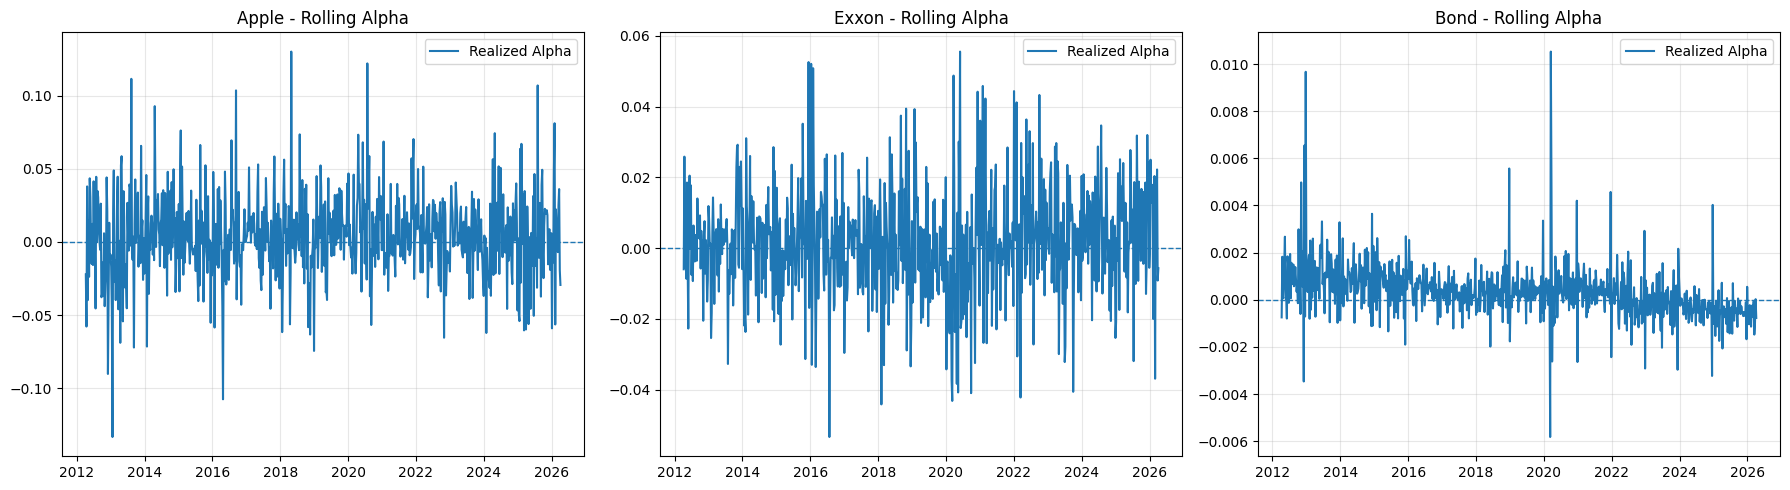

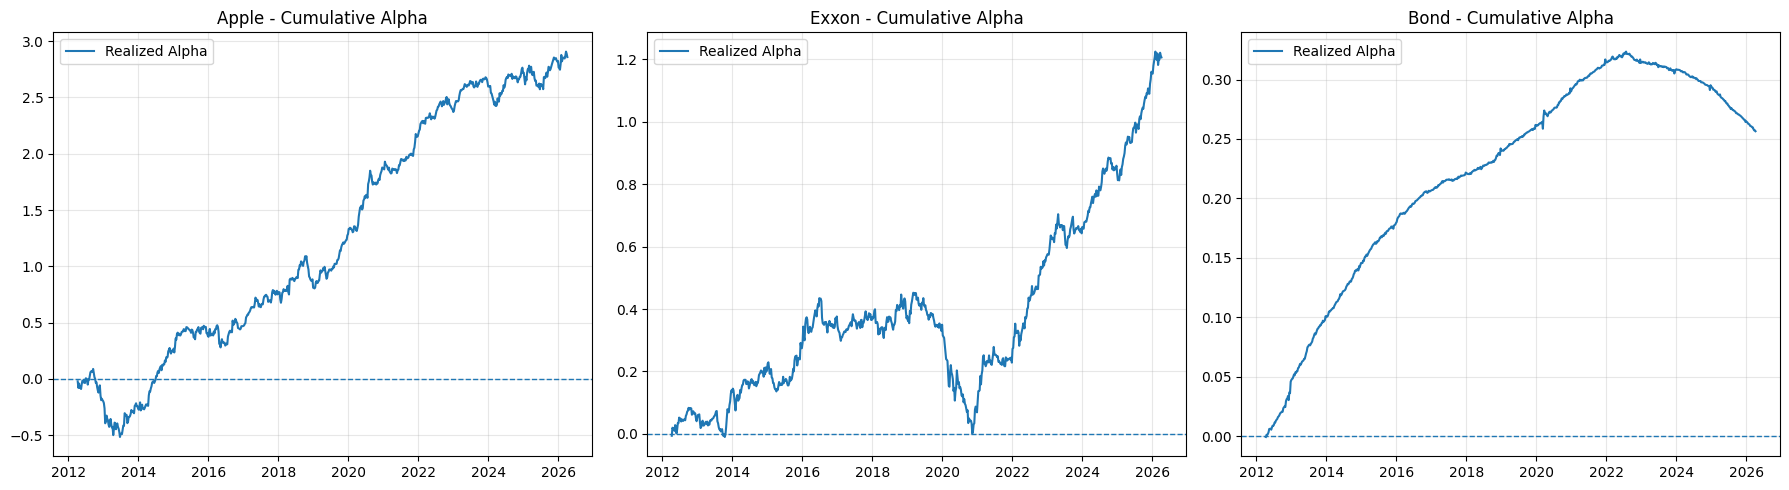

In [ ]:
# raw rolling alpha
plot_alpha_series(all_results, model_key="elastic_net_realized_alpha", cumulative=False)

# cumulative alpha
plot_alpha_series(all_results, model_key="elastic_net_realized_alpha", cumulative=True)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_predictions_all_assets(all_results):
    model_map = {
        "Linear":       "linear_predictions",
        "Ridge":        "ridge_predictions",
        "Elastic Net":  "elastic_net_predictions",
        "Random Forest":"rf_predictions",
        "XGBoost":      "xgb_predictions"   # verify this key
    }

    for asset_name, asset_results in all_results.items():
        fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
        axes = axes.flatten()

        for i, (model_name, key) in enumerate(model_map.items()):
            ax = axes[i]
            if key not in asset_results:
                ax.set_title(f"{asset_name} - {model_name} (NO DATA: '{key}')")
                ax.set_visible(True)
                continue

            pred_df = asset_results[key].copy()
            ax.plot(pred_df.index, pred_df["Actual"],    label="Actual")
            ax.plot(pred_df.index, pred_df["Predicted"], label="Predicted")
            ax.set_title(f"{asset_name} - {model_name}")
            ax.set_ylabel("Return")
            ax.grid(True, alpha=0.3)
            ax.legend()

        # Hide the unused 6th subplot
        axes[-1].set_visible(False)

        plt.suptitle(f"{asset_name}: Actual vs Predicted Returns", fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

In [ ]:
def combine_metrics_for_asset(asset_results):
    metric_map = {
        "Linear": "linear_results",
        "Ridge": "ridge_results",
        "Elastic Net": "elastic_net_results",
        "Random Forest": "rf_results",
        "XGBoost": "xgb_results"
    }

    frames = []
    for model_name, key in metric_map.items():
        df = asset_results[key].copy()
        df["model"] = model_name
        frames.append(df)

    out = pd.concat(frames, ignore_index=True)
    return out


def plot_metric_bars(all_results, dataset_filter="oos_2025"):
    metrics_to_plot = ["R2", "RMSE", "MAE", "Directional_Accuracy"]

    for asset_name, asset_results in all_results.items():
        metrics_df = combine_metrics_for_asset(asset_results)
        metrics_df = metrics_df[metrics_df["dataset"] == dataset_filter].copy()

        fig, axes = plt.subplots(3, 2, figsize=(14, 8))
        axes = axes.flatten()

        for ax, metric in zip(axes, metrics_to_plot):
            ax.bar(metrics_df["model"], metrics_df[metric])
            ax.set_title(f"{asset_name} - {dataset_filter} - {metric}")
            ax.tick_params(axis="x", rotation=20)
            ax.grid(True, axis="y", alpha=0.3)

        plt.tight_layout()
        plt.show()

In [ ]:
def plot_single_metric_comparison(all_results, metric="R2", dataset_filter="oos_2025"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

    for ax, (asset_name, asset_results) in zip(axes, all_results.items()):
        metrics_df = combine_metrics_for_asset(asset_results)
        metrics_df = metrics_df[metrics_df["dataset"] == dataset_filter].copy()

        ax.bar(metrics_df["model"], metrics_df[metric])
        ax.set_title(f"{asset_name} - {metric} ({dataset_filter})")
        ax.tick_params(axis="x", rotation=20)
        ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

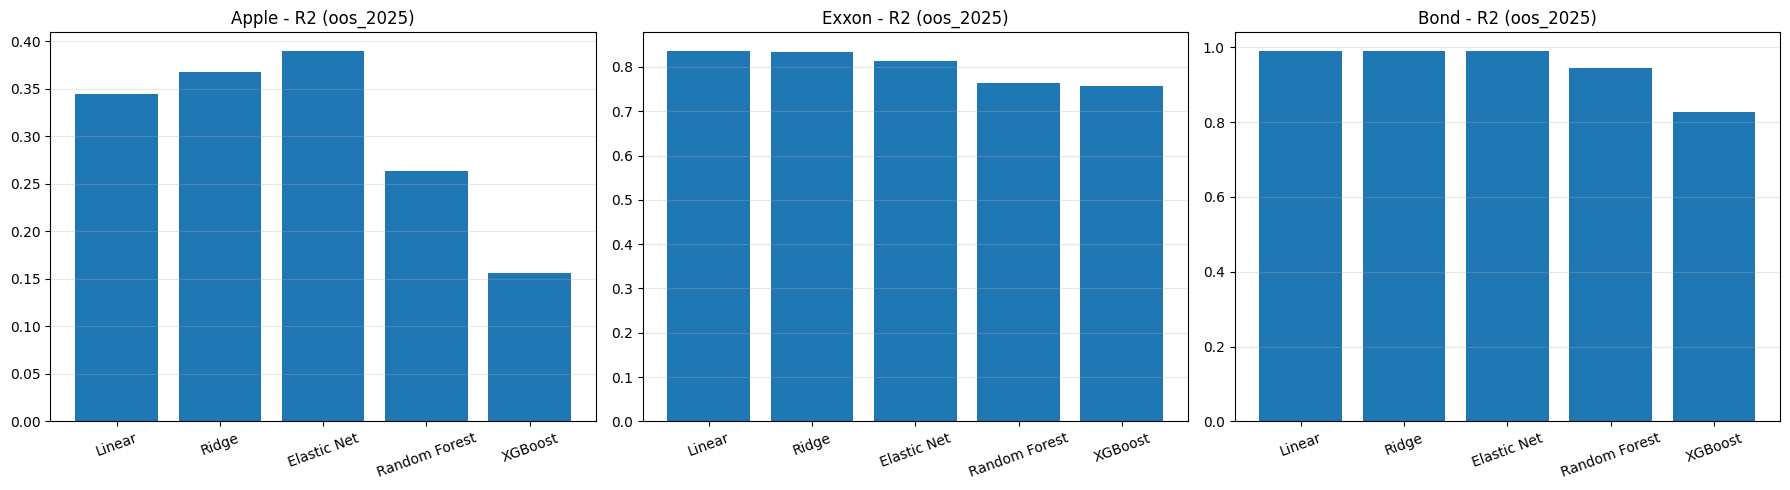

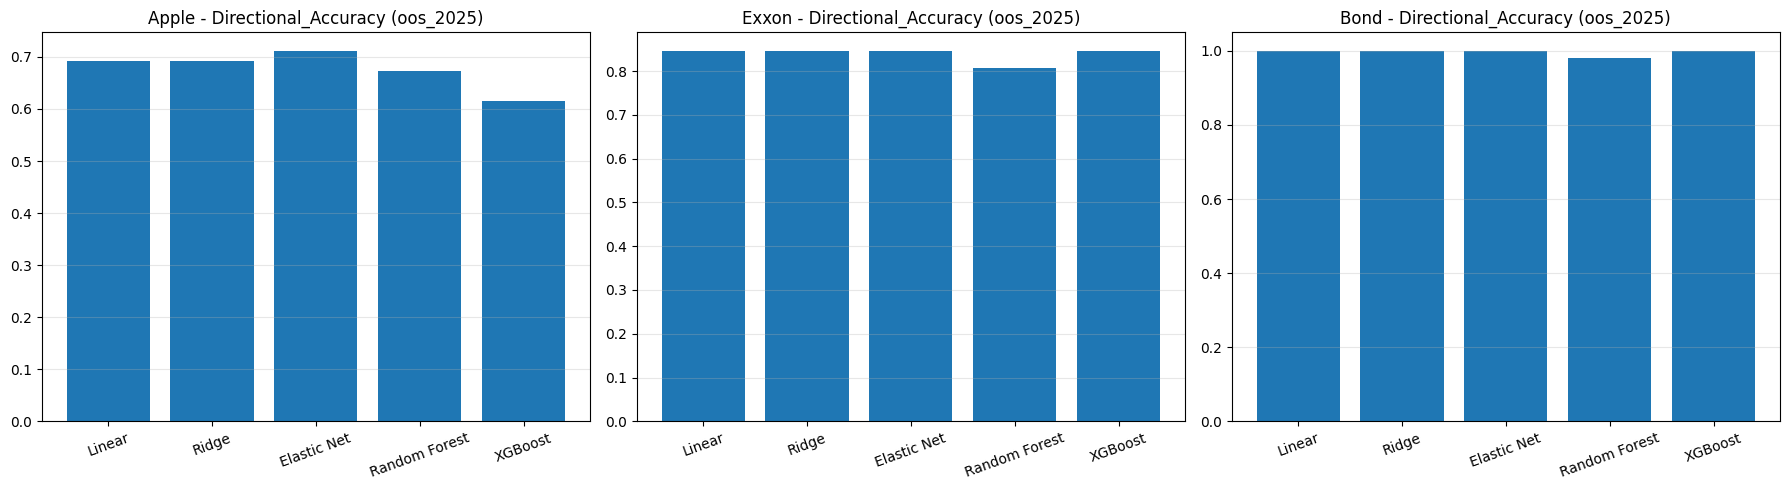

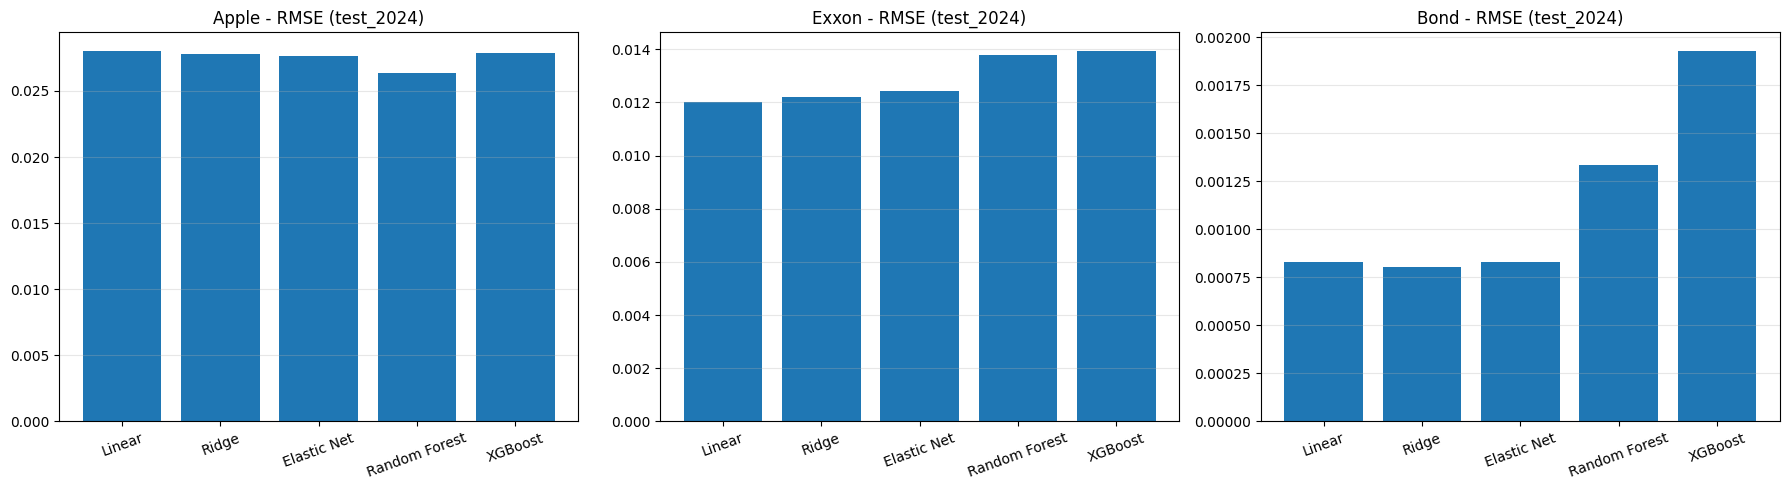

In [ ]:
plot_single_metric_comparison(all_results, metric="R2", dataset_filter="oos_2025")
plot_single_metric_comparison(all_results, metric="Directional_Accuracy", dataset_filter="oos_2025")
plot_single_metric_comparison(all_results, metric="RMSE", dataset_filter="test_2024")

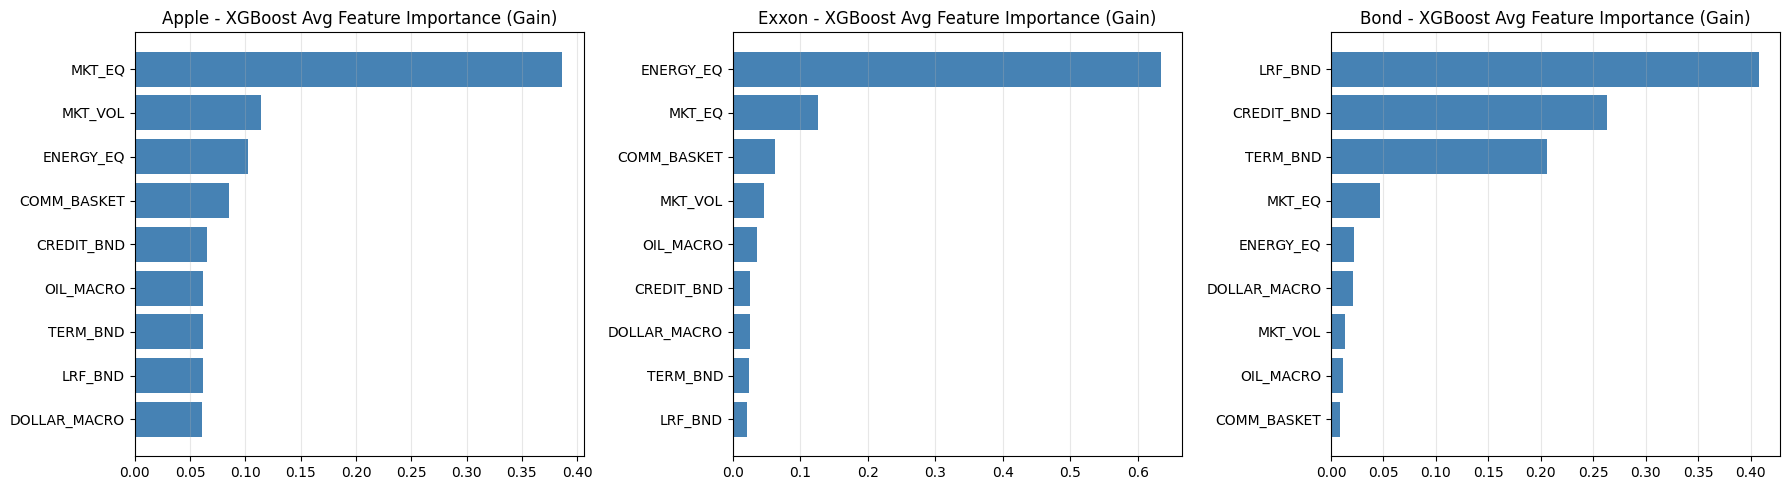

In [ ]:
def plot_xgb_feature_importance(all_results, top_n=10):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (asset_name, asset_results) in zip(axes, all_results.items()):
        imp_df = asset_results["xgb_feature_importance_avg"].head(top_n).copy()

        ax.barh(imp_df["feature"][::-1], imp_df["avg_importance"][::-1],
                color="steelblue")
        ax.set_title(f"{asset_name} - XGBoost Avg Feature Importance (Gain)")
        ax.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_xgb_feature_importance(all_results, top_n=10)

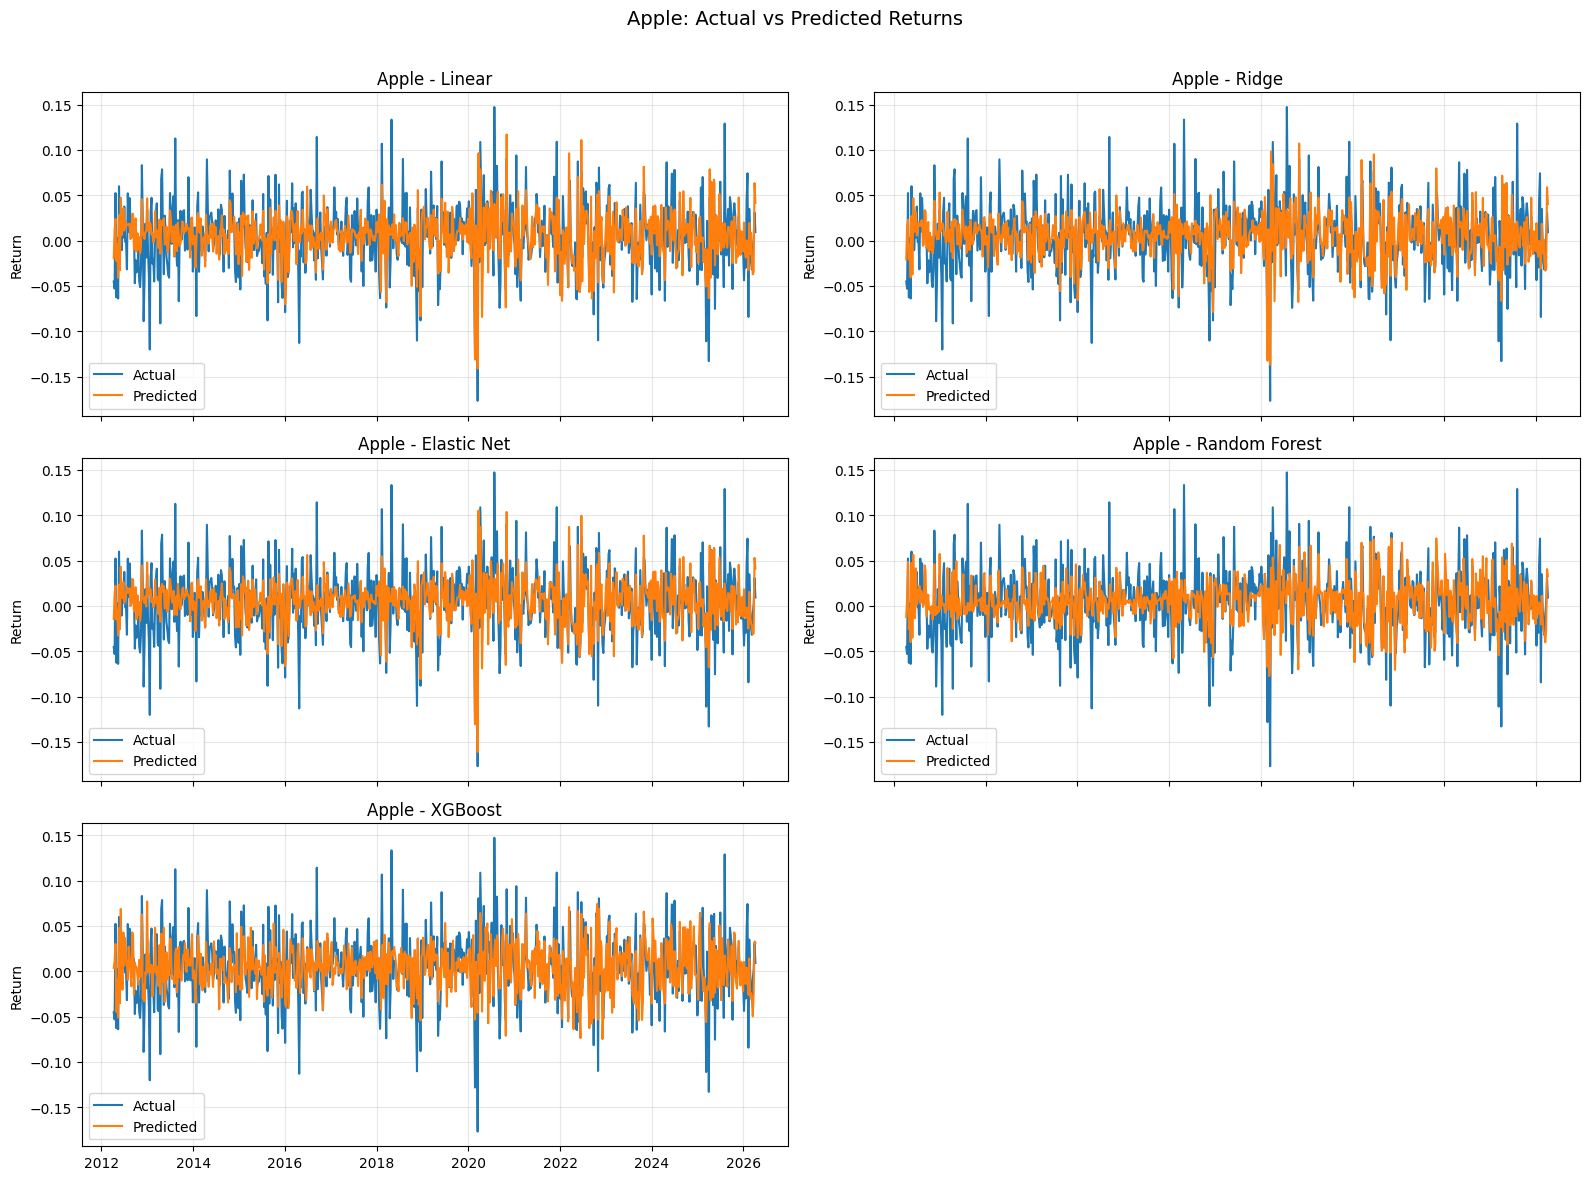

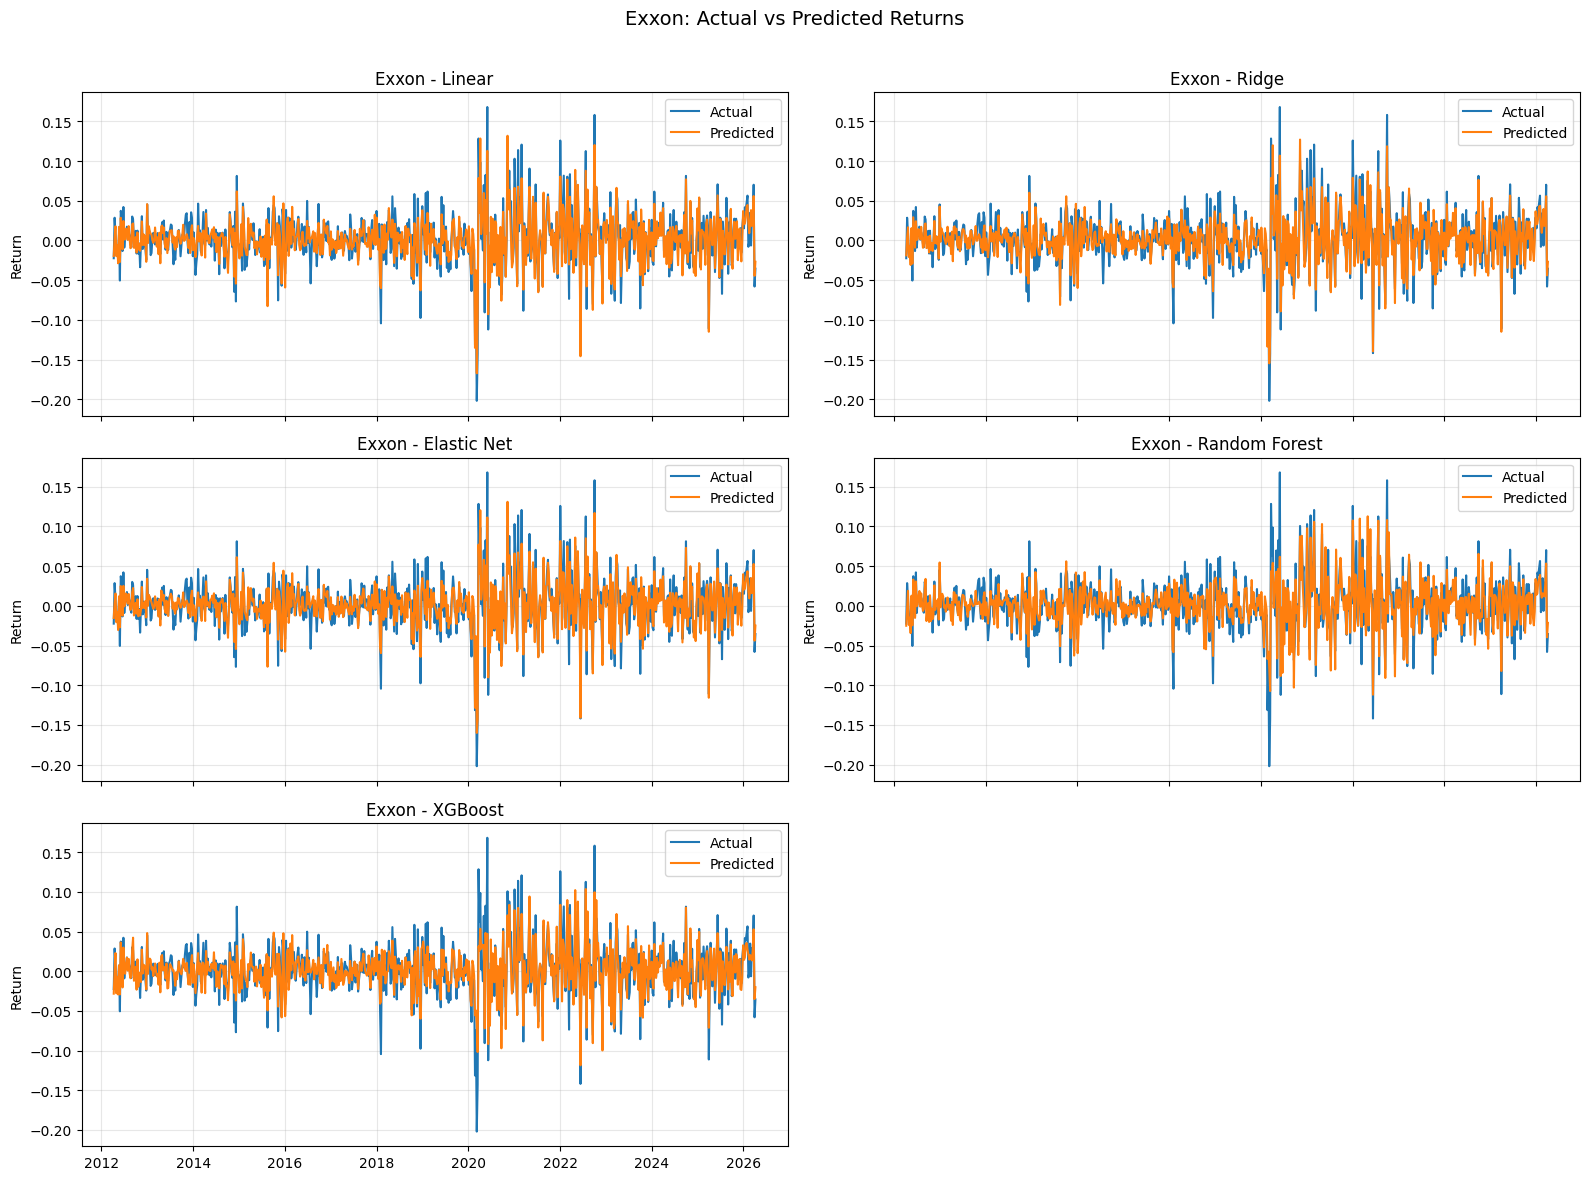

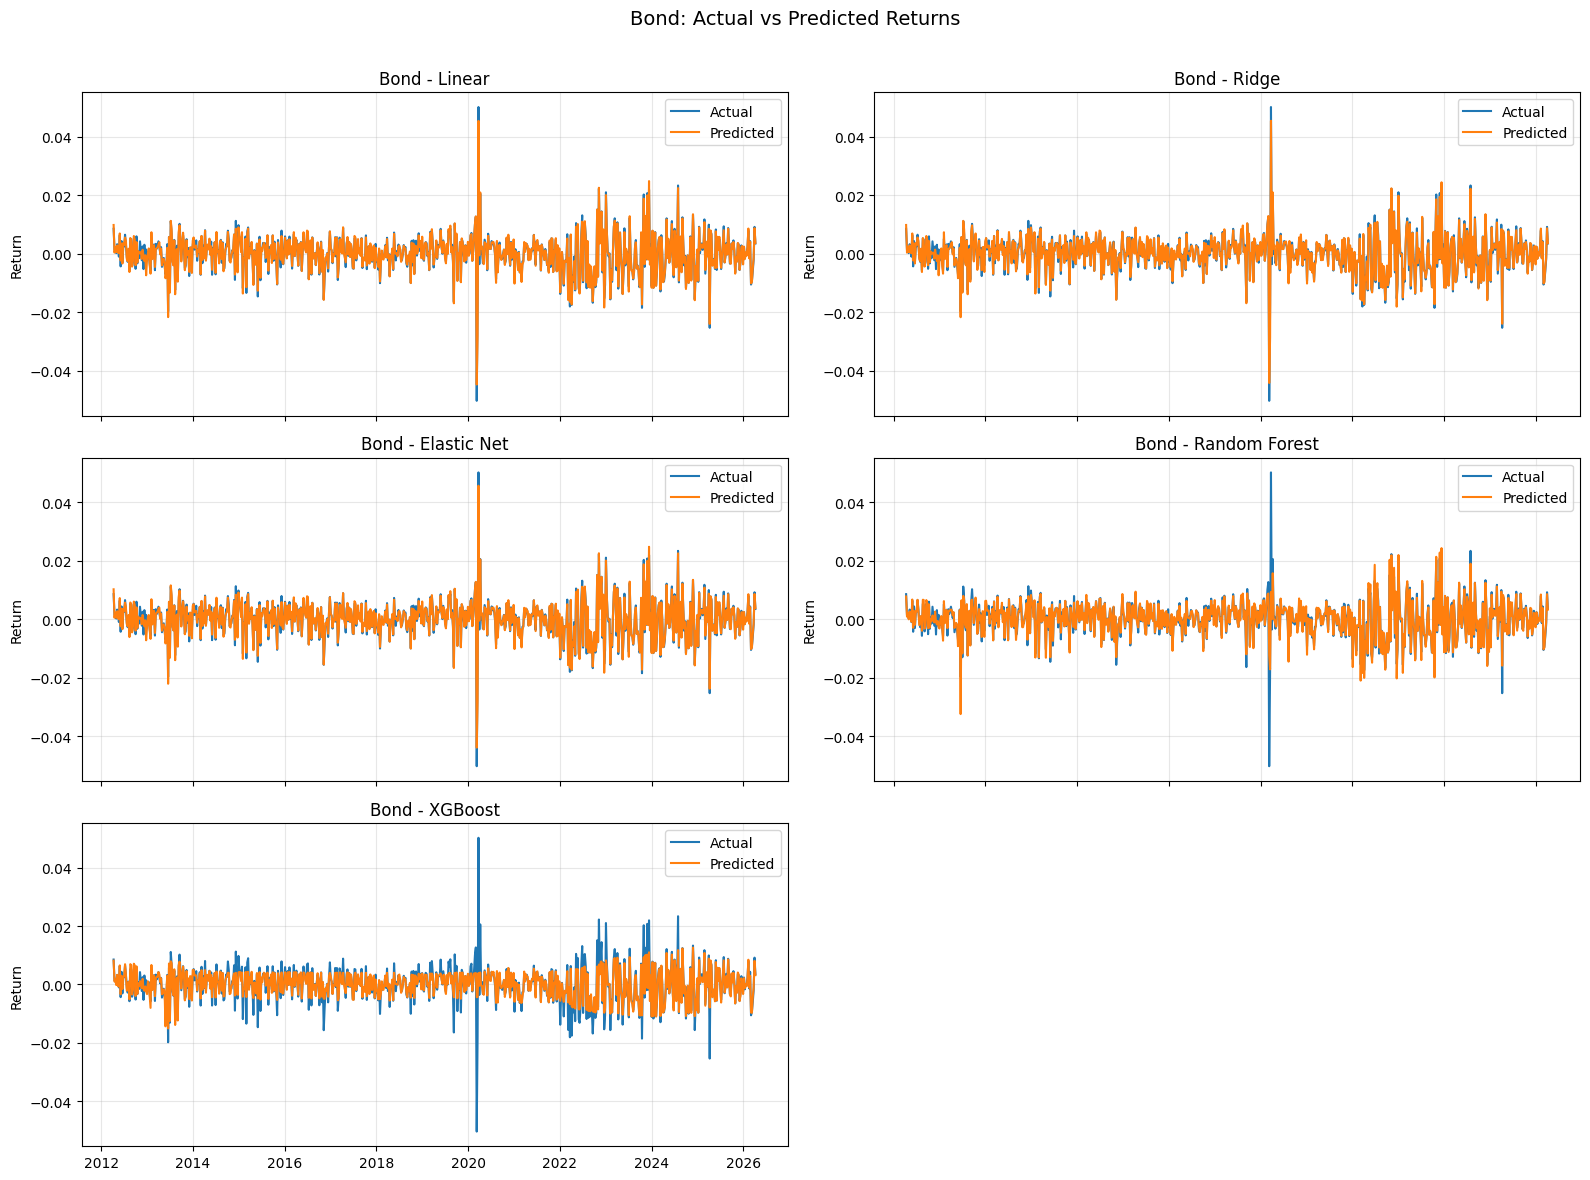

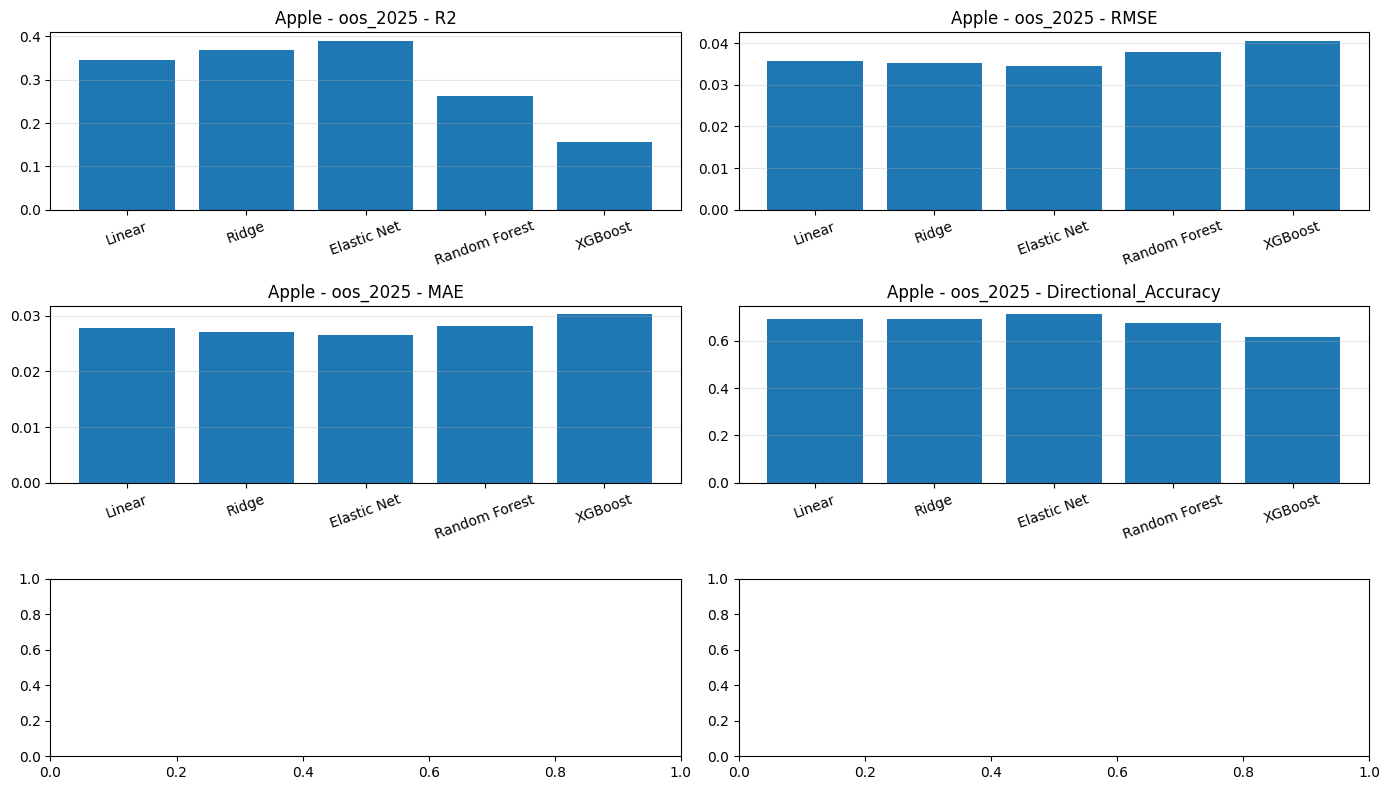

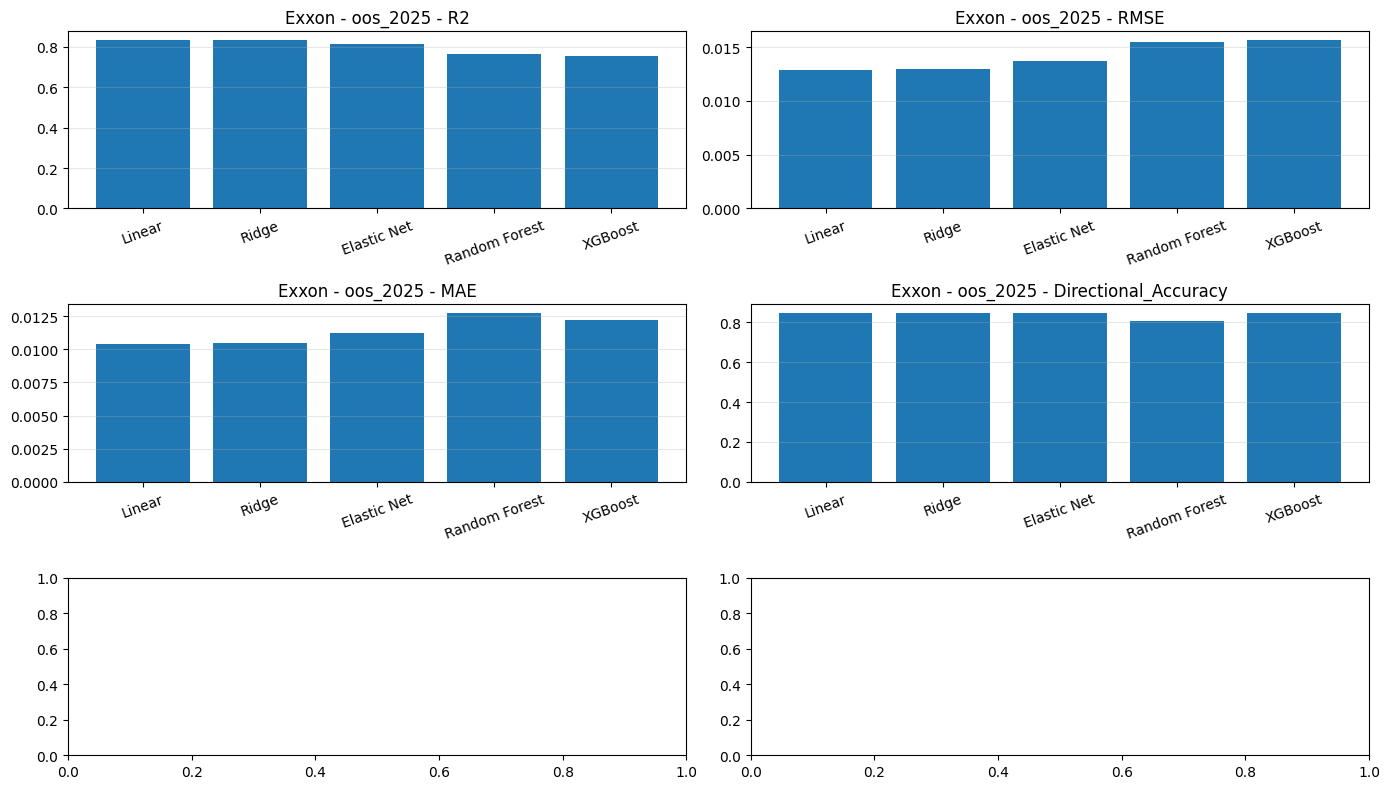

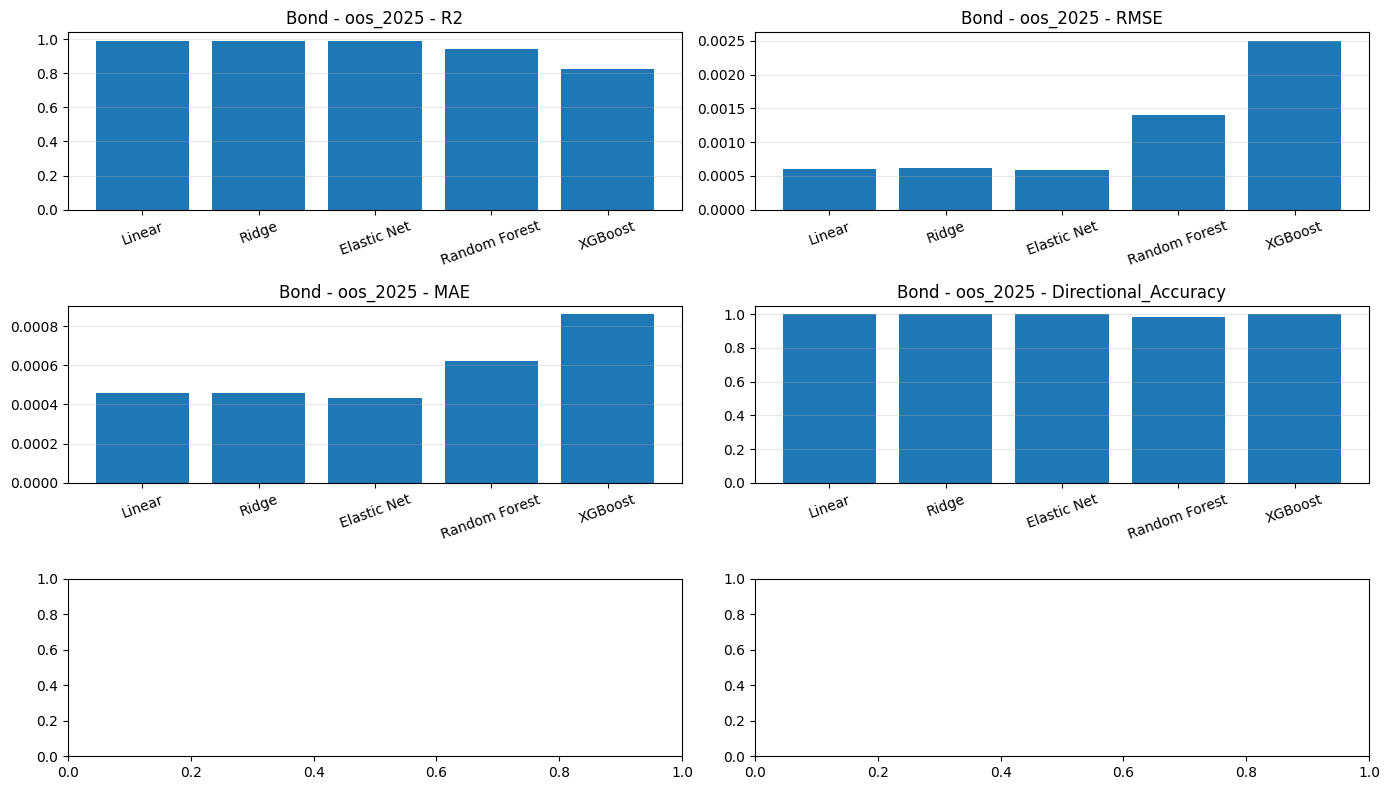

In [ ]:
def build_master_metrics_table(all_results):
    rows = []

    metric_map = {
        "Linear": "linear_results",
        "Ridge": "ridge_results",
        "Elastic Net": "elastic_net_results",
        "Random Forest": "rf_results",
        "XGBoost": "xgb_results"
    }

    for asset_name, asset_results in all_results.items():
        for model_name, key in metric_map.items():
            df = asset_results[key].copy()
            df["asset"] = asset_name
            df["model"] = model_name
            rows.append(df)

    master = pd.concat(rows, ignore_index=True)
    return master

master_metrics = build_master_metrics_table(all_results)
master_metrics
plot_predictions_all_assets(all_results)
plot_metric_bars(all_results, dataset_filter="oos_2025")
